In [11]:
#Finding methylation sites

In [17]:
import os
import requests
import shutil
import pandas as pd

BASE_DIR      = r"C:\Users\jlapi\Desktop\HM450"
MANIFEST_PATH = os.path.join(BASE_DIR, "HM450_manifest.csv")
OUTPUT_CSV    = os.path.join(BASE_DIR, "CA9_probes.csv")
REGIONS_CSV   = os.path.join(BASE_DIR, "CA9_cpg_regions.csv")
MANIFEST_URL  = (
    "https://webdata.illumina.com/downloads/productfiles/"
    "humanmethylation450/humanmethylation450_15017482_v1-2.csv"
)
GENE_NAME  = "CA9"
SHORE_SIZE = 2000  # bp each side of island
SHELF_SIZE = 2000  # bp each side of shore

os.makedirs(BASE_DIR, exist_ok=True)

# Download manifest
if not os.path.exists(MANIFEST_PATH):
    print("Downloading HM450 manifest (~30 MB)...")
    with requests.get(MANIFEST_URL, stream=True) as r:
        r.raise_for_status()
        with open(MANIFEST_PATH, "wb") as f:
            shutil.copyfileobj(r.raw, f)
    print(f"Saved: {MANIFEST_PATH}")
else:
    print("Manifest already present, skipping download.")

# Find header row
skip = 0
with open(MANIFEST_PATH, "rt", encoding="latin-1") as fh:
    for line in fh:
        if line.startswith("IlmnID") or line.startswith('"IlmnID"'):
            break
        skip += 1

manifest = pd.read_csv(MANIFEST_PATH, skiprows=skip, encoding="latin-1", low_memory=False)
manifest.columns = manifest.columns.str.strip().str.replace('"', "")

# Find all CA4-annotated probes (exact gene match, chr17 only)
ca4 = manifest[
    manifest["UCSC_RefGene_Name"]
        .str.split(";")
        .apply(lambda x: isinstance(x, list) and "CA9" in x)
    & (manifest["CHR"].astype(str) == "9")
][[
    "IlmnID", "CHR", "MAPINFO",
    "UCSC_RefGene_Name", "UCSC_RefGene_Group",
    "Relation_to_UCSC_CpG_Island", "UCSC_CpG_Islands_Name"
]].sort_values("MAPINFO").reset_index(drop=True)

print(f"\nAll CpG sites annotated to {GENE_NAME}: {len(ca4)}")
print(ca4.to_string(index=False))

ca4.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved probes to: {OUTPUT_CSV}")

# Derive exact CpG region boundaries from island name
island_names = ca4["UCSC_CpG_Islands_Name"].dropna().unique()

regions = []
for island in island_names:
    try:
        chrom, coords = island.strip().split(":")
        isl_start, isl_end = [int(x) for x in coords.split("-")]
    except ValueError:
        print(f"Could not parse island name: {island}")
        continue

    regions.append(("Island",  chrom, isl_start,                              isl_end,                          island))
    regions.append(("N_Shore", chrom, isl_start - SHORE_SIZE,                 isl_start - 1,                    island))
    regions.append(("S_Shore", chrom, isl_end   + 1,                          isl_end   + SHORE_SIZE,           island))
    regions.append(("N_Shelf", chrom, isl_start - SHORE_SIZE - SHELF_SIZE,    isl_start - SHORE_SIZE - 1,       island))
    regions.append(("S_Shelf", chrom, isl_end   + SHORE_SIZE + 1,             isl_end   + SHORE_SIZE + SHELF_SIZE, island))

regions_df = pd.DataFrame(regions, columns=["Region", "CHR", "Start", "End", "Island_Name"])

print(f"\nDerived CpG region boundaries:")
print(regions_df.to_string(index=False))

regions_df.to_csv(REGIONS_CSV, index=False)
print(f"\nSaved regions to: {REGIONS_CSV}")

Manifest already present, skipping download.

All CpG sites annotated to CA9: 7
    IlmnID CHR    MAPINFO UCSC_RefGene_Name UCSC_RefGene_Group Relation_to_UCSC_CpG_Island  UCSC_CpG_Islands_Name
cg19257550   9 35673909.0               CA9             TSS200                     N_Shore chr9:35675648-35676375
cg20610181   9 35674000.0               CA9            1stExon                     N_Shore chr9:35675648-35676375
cg06908460   9 35676104.0               CA9               Body                      Island chr9:35675648-35676375
cg13849253   9 35676166.0               CA9               Body                      Island chr9:35675648-35676375
cg09566069   9 35676365.0               CA9               Body                      Island chr9:35675648-35676375
cg14563831   9 35679275.0               CA9               Body                     S_Shelf chr9:35675648-35676375
cg13938361   9 35679915.0               CA9               Body                     S_Shelf chr9:35675648-35676375

Saved p

In [1]:
# Location of methylation sites

CA9 | Strand: + | TSS: 35673928 | Exons: 11
Figure saved to: C:\Users\jlapi\Desktop\HM450\CA9_methylation_probes.png


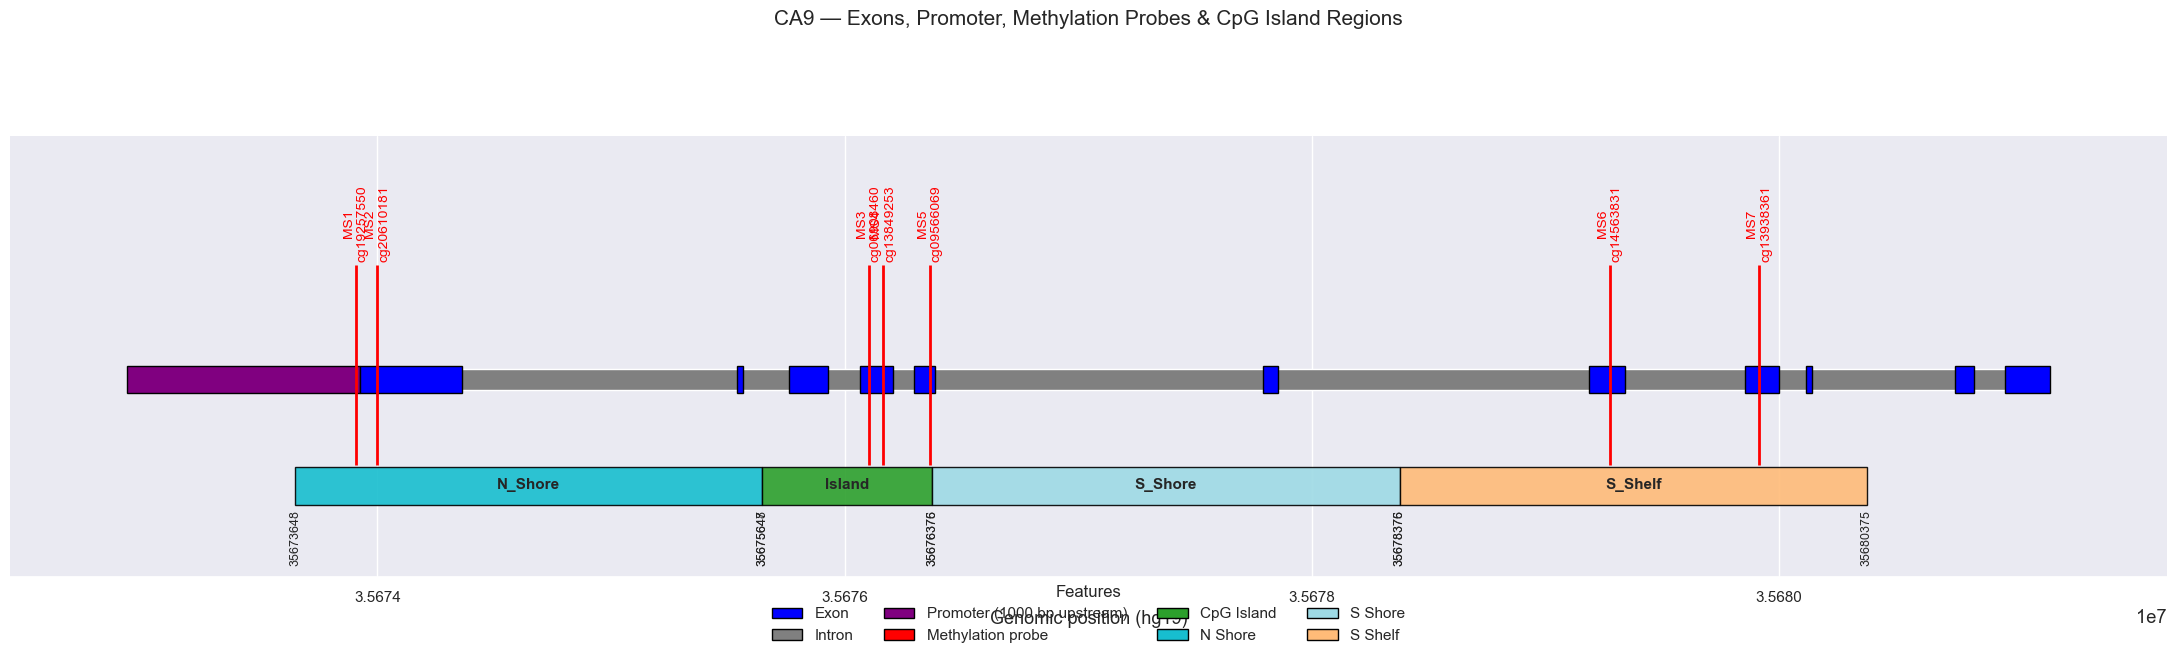

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE_DIR   = r"C:\Users\jlapi\Desktop\HM450"
GTF_PATH   = os.path.join(BASE_DIR, "gencode.v36.primary_assembly.annotation.gtf")
OUTPUT_FIG = os.path.join(BASE_DIR, "CA9_methylation_probes.png")

GENE_NAME         = "CA9"
TARGET_TRANSCRIPT = "ENST00000378357.9"
PROMOTER_UPSTREAM = 1000

PROBE_IDS = [
    "cg19257550", "cg20610181", "cg06908460", "cg13849253",
    "cg09566069", "cg14563831", "cg13938361",
]
MS_LABELS = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}
CPG_REGIONS = [
    ("N_Shore", 35673648, 35675647, "#17becf"),
    ("Island",  35675648, 35676375, "#2ca02c"),
    ("S_Shore", 35676376, 35678375, "#9edae5"),
    ("S_Shelf", 35678376, 35680375, "#ffbb78"),
]

# Load probe positions
df = pd.read_csv(os.path.join(BASE_DIR, "CA9_probes.csv"))
df = df[df["IlmnID"].isin(PROBE_IDS)].sort_values("MAPINFO")
probes = [(row["IlmnID"], int(row["MAPINFO"])) for _, row in df.iterrows()]

# Parse GTF
exons, tss, strand = [], None, None

with open(GTF_PATH, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        cols = line.strip().split("\t")
        if len(cols) != 9:
            continue

        feature = cols[2]
        if feature not in ("exon", "transcript"):
            continue

        start, end, strand_col, attrs = int(cols[3]), int(cols[4]), cols[6], cols[8]

        # Parse attributes
        attr_dict = {}
        for kv in attrs.split(";"):
            parts = kv.strip().split()
            if len(parts) == 2:
                attr_dict[parts[0]] = parts[1].strip('"')

        if attr_dict.get("gene_name") != GENE_NAME:
            continue
        if attr_dict.get("transcript_id") != TARGET_TRANSCRIPT:
            continue

        if feature == "exon":
            exons.append((start, end))
        elif feature == "transcript":
            strand = strand_col
            tss = start if strand_col == "+" else end

if not exons or tss is None:
    raise ValueError(f"Transcript {TARGET_TRANSCRIPT} not found in GTF.")

exons = sorted(exons)
promoter_start = tss - PROMOTER_UPSTREAM if strand == "+" else tss
promoter_end   = tss if strand == "+" else tss + PROMOTER_UPSTREAM

print(f"{GENE_NAME} | Strand: {strand} | TSS: {tss} | Exons: {len(exons)}")

# Plot
probe_positions = [pos for _, pos in probes]
min_x = min(promoter_start, exons[0][0],  min(probe_positions)) - 500
max_x = max(promoter_end,   exons[-1][1], max(probe_positions)) + 500

GENE_Y = 1.0
CPG_Y  = 0.3

fig, ax = plt.subplots(figsize=(22, 7))

# CpG regions
for lbl, rs, re, col in CPG_REGIONS:
    ax.barh(CPG_Y, re - rs, left=rs, height=0.25,
            color=col, edgecolor="black", linewidth=1.0, zorder=2, alpha=0.9)
    ax.text((rs + re) / 2, CPG_Y + 0.01, lbl,
            ha="center", va="center", fontsize=11, fontweight="bold")
    for xpos, label in [(rs, str(rs)), (re, str(re))]:
        ax.text(xpos, CPG_Y - 0.16, label,
                ha="center", va="top", fontsize=9, rotation=90)

# Gene body
ax.barh(GENE_Y, exons[-1][1] - exons[0][0], left=exons[0][0],
        height=0.14, color="gray", zorder=1)

# Exons
for s, e in exons:
    ax.barh(GENE_Y, e - s, left=s, height=0.18,
            color="blue", edgecolor="black", linewidth=1.0, zorder=2)

# Promoter
ax.barh(GENE_Y, promoter_end - promoter_start, left=promoter_start,
        height=0.18, color="purple", edgecolor="black", linewidth=1.0, zorder=1)

# Probes
for probe_name, pos in probes:
    label = f"{MS_LABELS[probe_name]}\n{probe_name}"
    ax.vlines(pos, CPG_Y + 0.14, GENE_Y + 0.75, color="red", linewidth=2.0, zorder=3)
    ax.text(pos, GENE_Y + 0.77, label,
            rotation=90, fontsize=10, va="bottom", ha="center", color="red")

# Formatting
ax.set_xlabel("Genomic position (hg19)", fontsize=13)
ax.set_title(
    f"{GENE_NAME} — Exons, Promoter, Methylation Probes & CpG Island Regions",
    pad=80, fontsize=15,
)
ax.set_xlim(min_x, max_x)
ax.set_ylim(-0.3, 2.6)
ax.get_yaxis().set_visible(False)
for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", labelsize=11)

# Legend
legend_elements = [
    Patch(facecolor="blue",    edgecolor="black", label="Exon"),
    Patch(facecolor="gray",    edgecolor="black", label="Intron"),
    Patch(facecolor="purple",  edgecolor="black", label=f"Promoter ({PROMOTER_UPSTREAM} bp upstream)"),
    Patch(facecolor="red",     edgecolor="black", label="Methylation probe"),
    Patch(facecolor="#2ca02c", edgecolor="black", label="CpG Island"),
    Patch(facecolor="#17becf", edgecolor="black", label="N Shore"),
    Patch(facecolor="#9edae5", edgecolor="black", label="S Shore"),
    Patch(facecolor="#ffbb78", edgecolor="black", label="S Shelf"),
]
ax.legend(handles=legend_elements, loc="lower center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False,
          fontsize=11, title="Features", title_fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {OUTPUT_FIG}")
plt.show()

In [2]:
# Methylation sites and protein domain of CA9

        probe label chr       pos   feature  cds_pos  aa_pos  \
0  cg19257550   MS1   9  35673909  promoter      NaN     NaN   
1  cg20610181   MS2   9  35674000  CDS_exon     41.0    14.0   
2  cg06908460   MS3   9  35676104  CDS_exon    645.0   215.0   
3  cg13849253   MS4   9  35676166  CDS_exon    707.0   236.0   
4  cg09566069   MS5   9  35676365  CDS_exon    816.0   272.0   
5  cg14563831   MS6   9  35679275  CDS_exon    998.0   333.0   
6  cg13938361   MS7   9  35679915  CDS_exon   1127.0   376.0   

                     domain  
0                      None  
1                      None  
2  Alpha-carbonic anhydrase  
3  Alpha-carbonic anhydrase  
4  Alpha-carbonic anhydrase  
5  Alpha-carbonic anhydrase  
6  Alpha-carbonic anhydrase  


C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3919704430.py:128: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


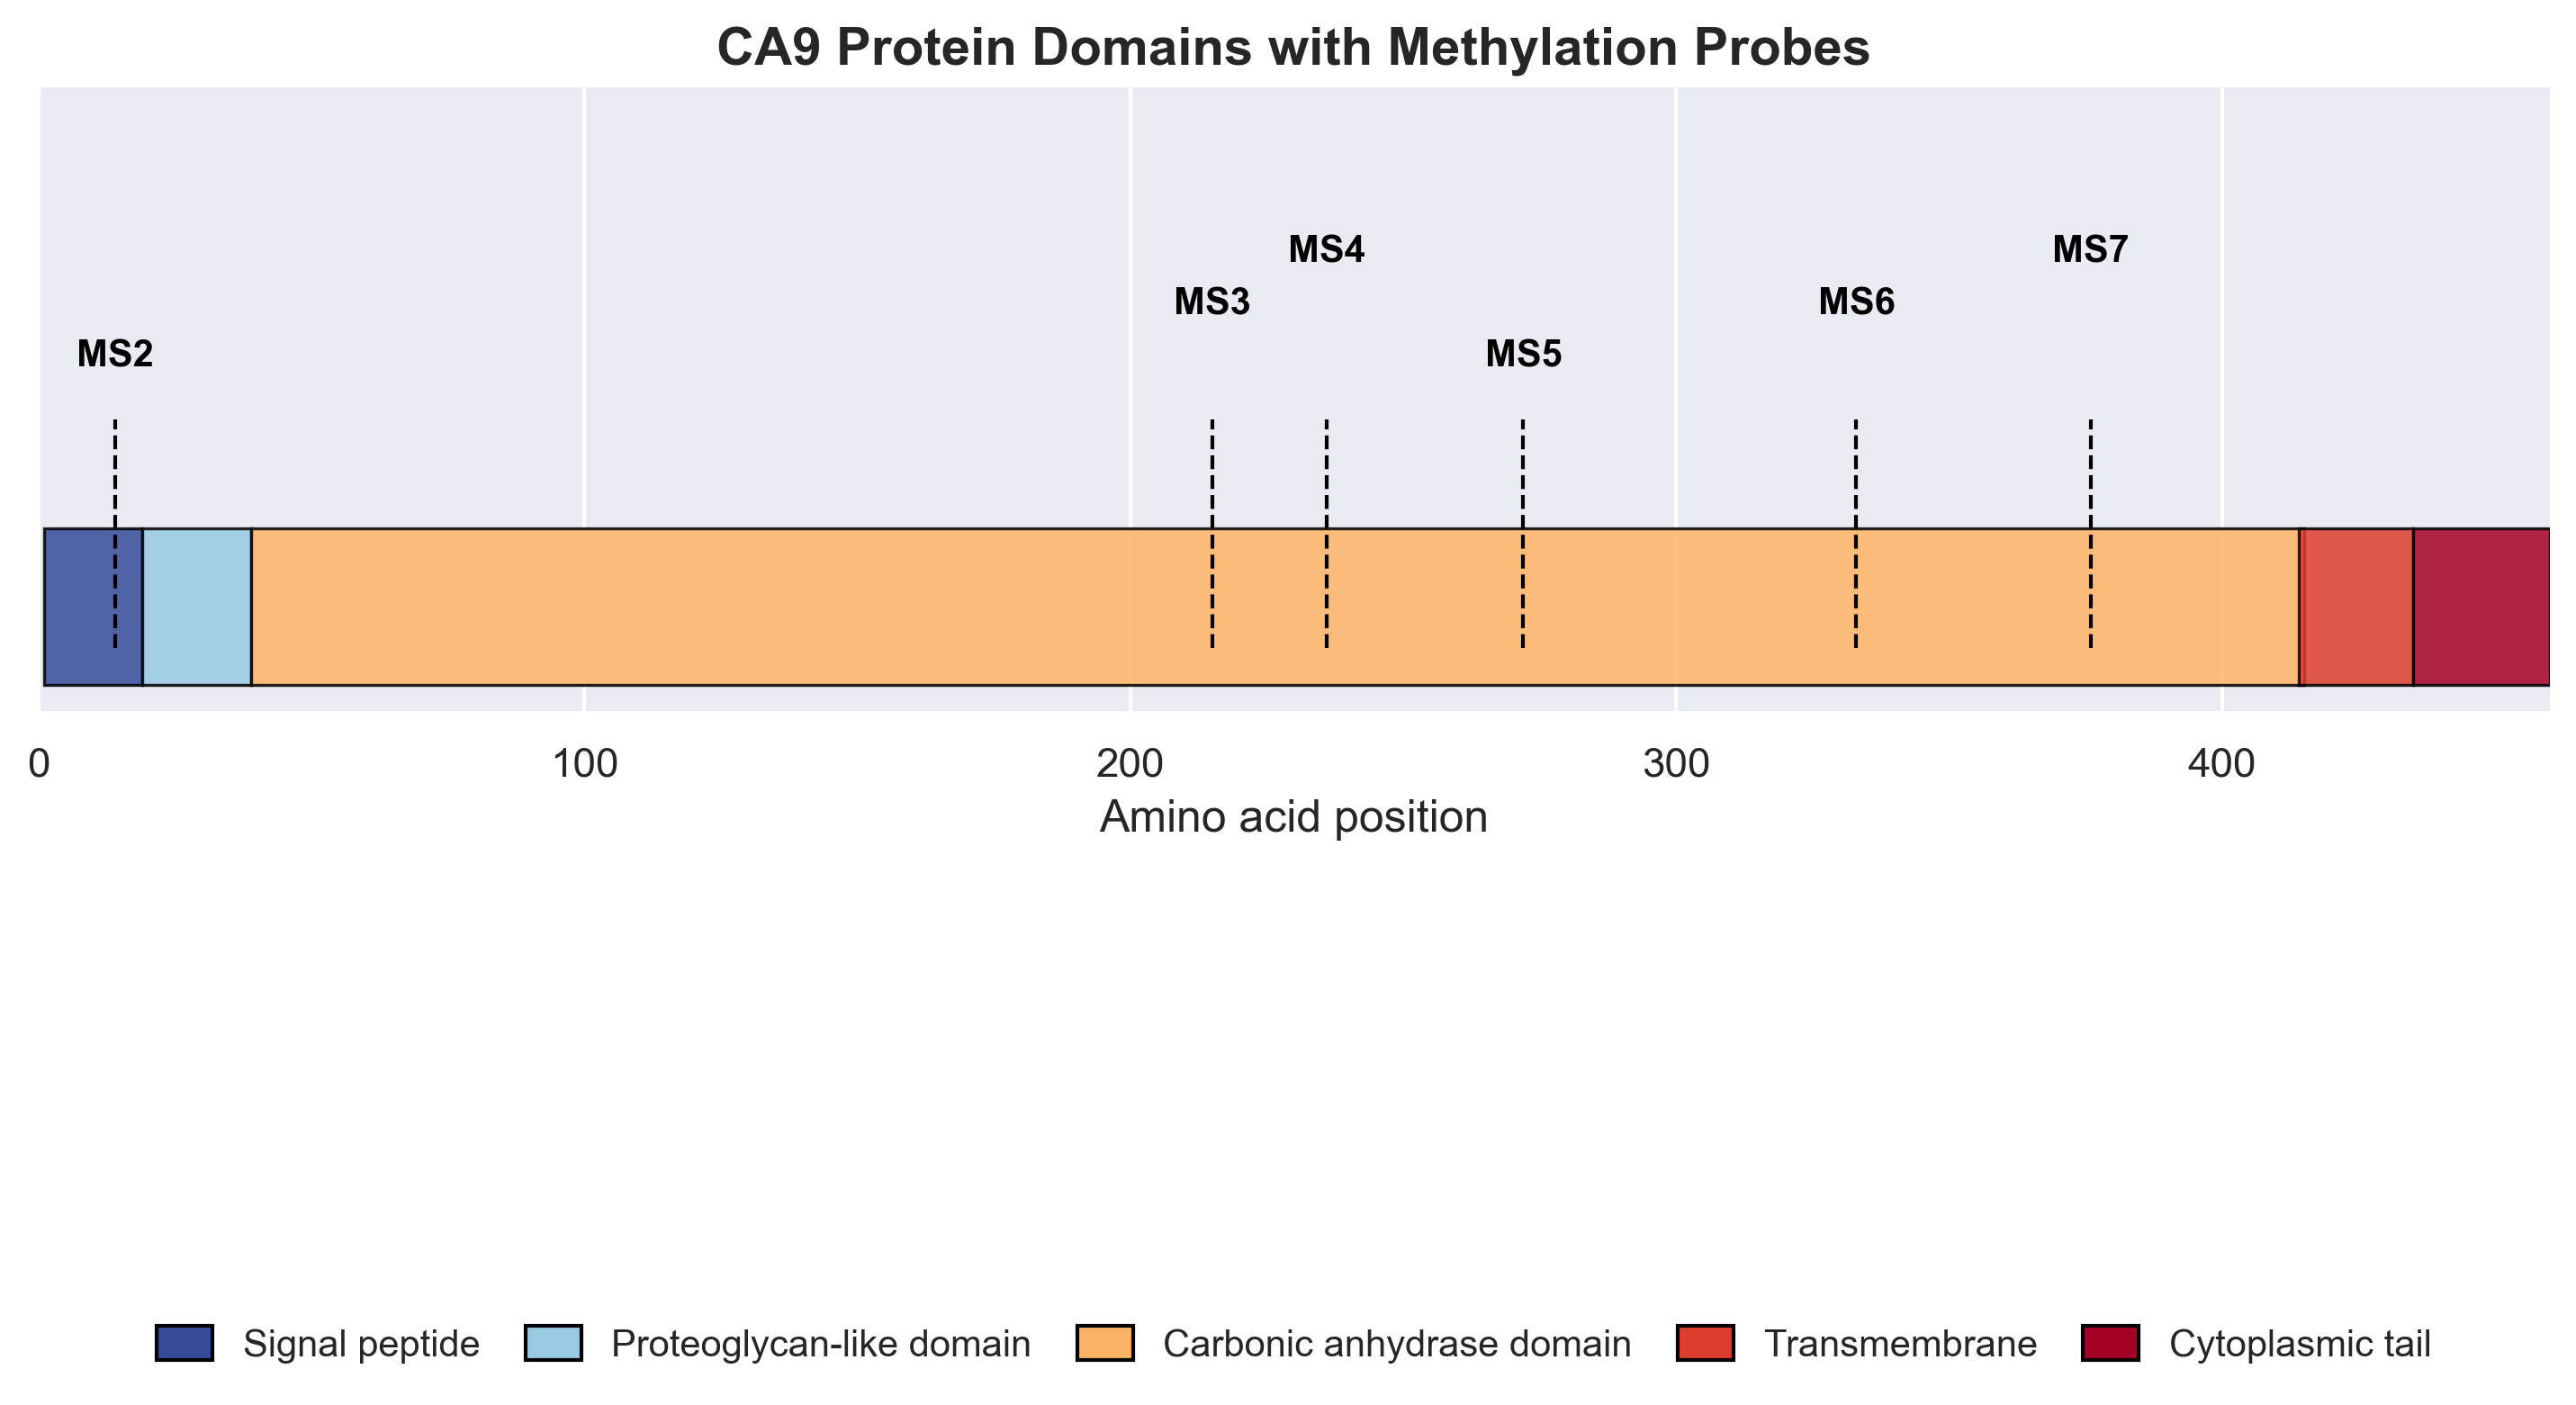

In [8]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── Probe coordinates ─────────────────────────────────────────────────────────
probes = pd.DataFrame({
    "probe": ["cg19257550", "cg20610181", "cg06908460", "cg13849253", "cg09566069", "cg14563831", "cg13938361"],
    "label": ["MS1", "MS2", "MS3", "MS4", "MS5", "MS6", "MS7"],
    "chr":   ["9"] * 7,
    "pos":   [35673909, 35674000, 35676104, 35676166, 35676365, 35679275, 35679915],
})

# ── Fetch CA9 gene info from Ensembl ─────────────────────────────────────────
HEADERS = {"Content-Type": "application/json", "Accept": "application/json"}

r = requests.get("https://rest.ensembl.org/lookup/symbol/human/CA9", headers=HEADERS, params={"expand": 1})
r.raise_for_status()
ca9_data = r.json()

tx_id = "ENST00000378357"
tx = next((t for t in ca9_data["Transcript"] if t["id"] == tx_id), None)
if tx is None or not tx.get("Exon"):
    raise ValueError(f"Transcript {tx_id} not found or has no exon data")

exons = [(e["start"], e["end"]) for e in tx["Exon"]]
translation = tx.get("Translation")
if not translation:
    raise ValueError(f"No translation info for transcript {tx_id}")

cds_start, cds_end = translation["start"], translation["end"]
gene_start, gene_end, strand = ca9_data["start"], ca9_data["end"], ca9_data["strand"]
cds_ranges = [(max(a, cds_start), min(b, cds_end)) for a, b in exons if max(a, cds_start) <= min(b, cds_end)]

def in_ranges(pos, ranges):
    return any(a <= pos <= b for a, b in ranges)

def build_cds_map(cds_ranges, strand):
    positions = []
    for a, b in sorted(cds_ranges, reverse=(strand == -1)):
        positions.extend(range(a, b + 1) if strand == 1 else range(b, a - 1, -1))
    return {gpos: idx + 1 for idx, gpos in enumerate(positions)}

g2c = build_cds_map(cds_ranges, strand)

# ── Annotate probes ───────────────────────────────────────────────────────────
records = []
for _, row in probes.iterrows():
    pos = row.pos
    if pos < gene_start - 2000 or pos > gene_end + 2000:
        feature, cds_pos, aa_pos = "outside_gene", None, None
    elif gene_start - 2000 <= pos < gene_start:
        feature, cds_pos, aa_pos = "promoter", None, None
    elif in_ranges(pos, cds_ranges):
        feature  = "CDS_exon"
        cds_pos  = g2c.get(pos)
        aa_pos   = (cds_pos - 1) // 3 + 1 if cds_pos else None
    elif in_ranges(pos, exons):
        feature, cds_pos, aa_pos = "UTR_exon", None, None
    else:
        feature, cds_pos, aa_pos = "intron", None, None
    records.append({"probe": row.probe, "label": row.label, "chr": row.chr,
                    "pos": pos, "feature": feature, "cds_pos": cds_pos, "aa_pos": aa_pos})

probe_annot = pd.DataFrame(records)

# ── Fetch CA9 domains from UniProt ────────────────────────────────────────────
r = requests.get("https://rest.uniprot.org/uniprotkb/Q16790.json")
r.raise_for_status()
uniprot_data = r.json()

uniprot_domains = [
    {"start": f["location"]["start"]["value"], "end": f["location"]["end"]["value"], "name": f.get("description", "")}
    for f in uniprot_data.get("features", [])
    if f.get("type") in ["Domain", "Region"]
]

def assign_domain(aa, domains):
    if aa is None:
        return None
    return next((d["name"] for d in domains if d["start"] <= aa <= d["end"]), None)

probe_annot["domain"] = probe_annot["aa_pos"].apply(lambda x: assign_domain(x, uniprot_domains))
print(probe_annot)

# ── CA9 domains for plotting ──────────────────────────────────────────────────
COLORS = ["#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", "#C2E4EF",
          "#EAECCC", "#FEDABB", "#FDB366", "#F67E4B", "#DD3D2D", "#A50026"]

domains = [
    {"name": "Signal peptide",            "start": 1,   "end": 18,  "color": COLORS[0]},
    {"name": "Proteoglycan-like domain",  "start": 19,  "end": 38,  "color": COLORS[3]},
    {"name": "Carbonic anhydrase domain", "start": 39,  "end": 414, "color": COLORS[7]},
    {"name": "Transmembrane",             "start": 414, "end": 434, "color": COLORS[9]},
    {"name": "Cytoplasmic tail",          "start": 435, "end": 459, "color": COLORS[10]},
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

bar_height = 0.3
y_offsets  = [0.45, 0.55, 0.65]

for d in domains:
    ax.barh(0, d["end"] - d["start"] + 1, left=d["start"], height=bar_height,
            color=d["color"], alpha=0.85, edgecolor="black", linewidth=0.8)

for i, (_, row) in enumerate(probe_annot.dropna(subset=["aa_pos"]).iterrows()):
    ax.plot([row.aa_pos, row.aa_pos], [-0.08, bar_height * 1.2],
            color="black", linestyle="--", linewidth=1.0)
    ax.text(row.aa_pos, y_offsets[i % 3], row.label,
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="black")

ax.set_xlim(0, 460)
ax.set_ylim(-0.2, 1.0)
ax.set_xlabel("Amino acid position", fontsize=12)
ax.set_yticks([])
ax.set_title("CA9 Protein Domains with Methylation Probes", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [Patch(facecolor=d["color"], edgecolor="black", label=d["name"]) for d in domains]
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -1.1),
          ncol=5, fontsize=10, frameon=False, handlelength=1.5, handleheight=1.0, columnspacing=1.2)

plt.tight_layout()
plt.show()

In [1]:
# Merging datasets

In [8]:
import pandas as pd
BASE_DIR = r"C:\Users\jlapi\Desktop\XENA2"
CANCER_TYPES = ["BRCA"]
ENSEMBL_ID = "ENSG00000107159.13"
METHYLATION_PROBES = [
    "cg19257550", "cg20610181", "cg06908460",
    "cg13849253", "cg09566069", "cg14563831", "cg13938361"
]

# PIPELINE
for cancer in CANCER_TYPES:
    print(f"\nProcessing {cancer}...")
    d = f"{BASE_DIR}\\{cancer}\\TCGA-{cancer}"

# Step 1: Extract CA9 expression and transpose
    df_expr = pd.read_csv(f"{d}.star_tpm.tsv", sep="\t", low_memory=False)
    df_expr = (
        df_expr[df_expr["Ensembl_ID"] == ENSEMBL_ID]
        .set_index("Ensembl_ID")
        .T
        .rename(columns={ENSEMBL_ID: "CA9_Expression"})
        .rename_axis("sample")
        .reset_index()
    )

# Step 2: Merge with clinical data
    df_clinical = pd.read_csv(f"{d}.clinical.tsv", sep="\t")
    df_merged = df_expr.merge(df_clinical, on="sample")

# Step 3: Merge with survival data
    df_survival = pd.read_csv(f"{d}.survival.tsv", sep="\t")
    df_merged = df_merged.merge(df_survival, on="sample")

# Step 4: Extract and transpose methylation probes
    df_meth = pd.read_csv(f"{d}.methylation450.tsv", sep="\t")
    df_meth = (
        df_meth[df_meth["Composite Element REF"].isin(METHYLATION_PROBES)]
        .set_index("Composite Element REF")
        .T
        .rename_axis("sample")
        .reset_index()
    )

# Step 5: Merge with methylation data and save
    df_final = df_merged.merge(df_meth, on="sample")
    output_path = f"{BASE_DIR}\\{cancer}\\{cancer}_final_merged.xlsx"
    df_final.to_excel(output_path, index=False)

    print(f"  Saved → {output_path}")
    print(df_final.head())

print("\nAll cancer types processed successfully.")


Processing BRCA...
  Saved → C:\Users\jlapi\Desktop\XENA2\BRCA\BRCA_final_merged.xlsx
             sample  CA9_Expression                                    id  \
0  TCGA-AQ-A0Y5-01A        5.415961  d0b78f3f-a198-437a-ab8c-204345d3b75d   
1  TCGA-C8-A274-01A        0.263275  dbcad60f-86c7-41e3-b0ae-baa39c9f83dd   
2  TCGA-B6-A1KC-01B        0.035483  1502c7d7-1535-4e56-9f34-30623acd50d5   
3  TCGA-AC-A62V-01A        0.341986  d5f2b85a-94a9-4168-bbe8-149ec71342b0   
4  TCGA-A2-A0YM-01A        5.249775  5cbf0aea-ebb4-4005-bdd5-14ef2dc6826c   

                   disease_type                               case_id  \
0  Ductal and Lobular Neoplasms  d0b78f3f-a198-437a-ab8c-204345d3b75d   
1  Ductal and Lobular Neoplasms  dbcad60f-86c7-41e3-b0ae-baa39c9f83dd   
2  Ductal and Lobular Neoplasms  1502c7d7-1535-4e56-9f34-30623acd50d5   
3  Ductal and Lobular Neoplasms  d5f2b85a-94a9-4168-bbe8-149ec71342b0   
4  Ductal and Lobular Neoplasms  5cbf0aea-ebb4-4005-bdd5-14ef2dc6826c   

   submitte

In [3]:
# Correlation of methylation sites between each other

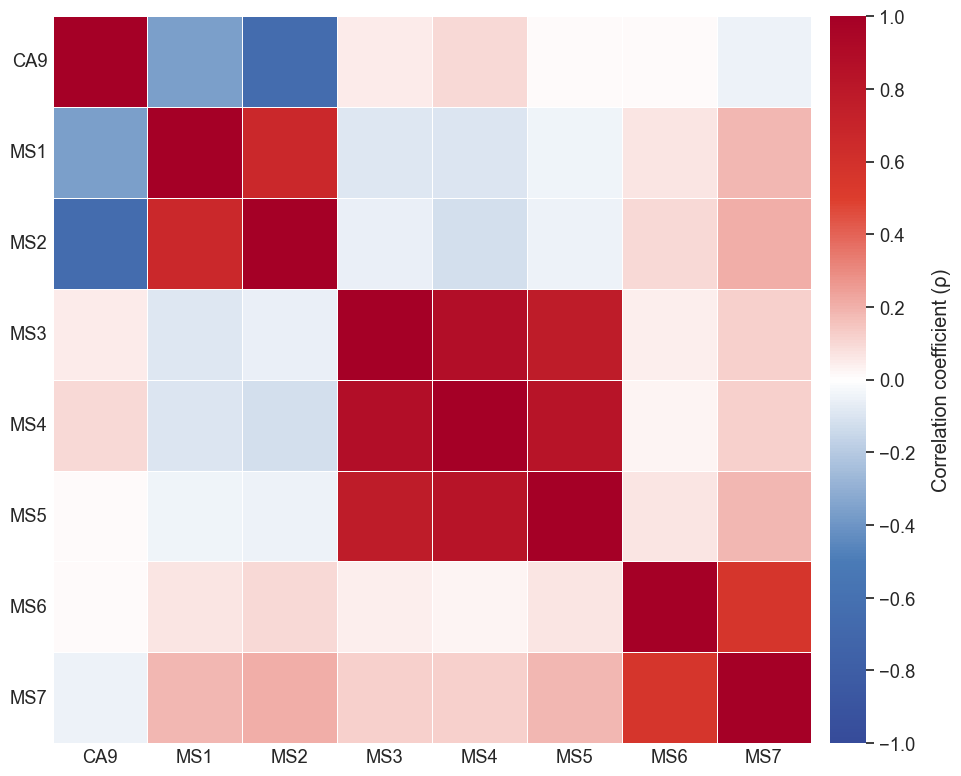

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from matplotlib.colors import LinearSegmentedColormap

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR = r"C:\Users\jlapi\Desktop\XENA"
FILE_PATTERN = os.path.join(BASE_DIR, "**", "*_final_merged.xlsx")

METHYLATION_SITES = {
    "cg19257550": "MS1",
    "cg20610181": "MS2",
    "cg06908460": "MS3",
    "cg13849253": "MS4",
    "cg09566069": "MS5",
    "cg14563831": "MS6",
    "cg13938361": "MS7",
}

EXPRESSION_COL = "CA9_Expression"
EXPRESSION_LABEL = "CA9"

COLORMAP = LinearSegmentedColormap.from_list(
    "custom_div", ["#364B9A", "#4A7BB7", "white", "#DD3D2D", "#A50026"], N=256
)

# ── Load data ─────────────────────────────────────────────────────────────────
all_files = glob.glob(FILE_PATTERN, recursive=True)
if not all_files:
    raise FileNotFoundError(f"No files found matching: {FILE_PATTERN}")

dfs = []
for f in all_files:
    df = pd.read_excel(f)
    df["Cancer_Type"] = os.path.basename(os.path.dirname(f))
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

# ── Prepare correlation matrix ────────────────────────────────────────────────
cols = [EXPRESSION_COL] + list(METHYLATION_SITES.keys())
missing = [c for c in cols if c not in combined.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data = combined[cols].apply(pd.to_numeric, errors="coerce").dropna()
data = data.rename(columns={EXPRESSION_COL: EXPRESSION_LABEL, **METHYLATION_SITES})
data = data[[EXPRESSION_LABEL] + list(METHYLATION_SITES.values())]

corr = data.corr(method="pearson").round(2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap=COLORMAP,
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"shrink": 1.0, "aspect": 20, "pad": 0.02},
)

cbar = ax.collections[0].colorbar
cbar.set_ticks(np.arange(-1.0, 1.01, 0.2))
cbar.ax.set_ylabel("Correlation coefficient (ρ)", labelpad=12)

ax.tick_params(axis="x", rotation=0, length=0)
ax.tick_params(axis="y", rotation=0, length=0)

plt.tight_layout()
plt.show()

In [ ]:
# Differences in methylation between normal tissue and primary tumours

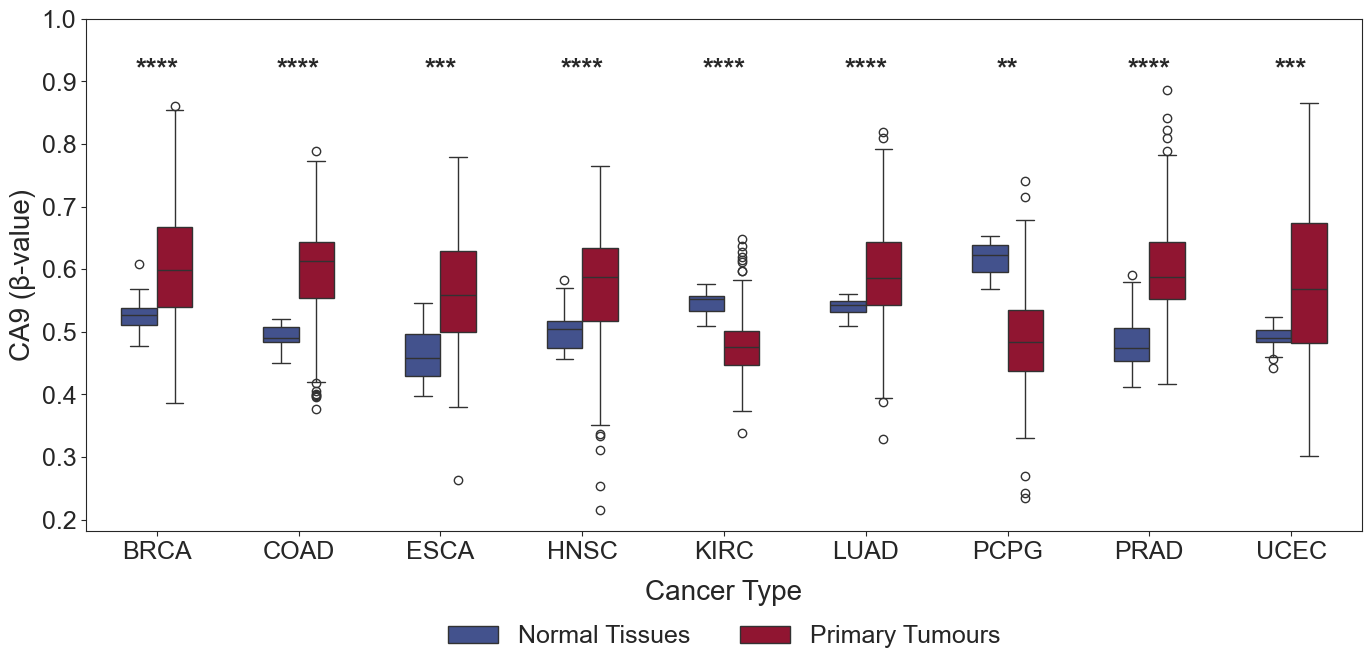

  Cancer_Type  Mann-Whitney U Statistic       p-value Significance
0        BRCA                   13083.0  4.817813e-19         ****
1        COAD                     595.0  3.077164e-08         ****
2        ESCA                     336.0  2.118321e-04          ***
3        HNSC                    2165.0  9.628136e-06         ****
4        KIRC                    6886.0  3.649277e-11         ****
5        LUAD                    2352.0  8.324977e-05         ****
6        PCPG                     501.0  3.456580e-03           **
7        PRAD                    1472.0  1.792085e-16         ****
8        UCEC                    2679.0  5.776808e-04          ***


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16

cancer_types = [
    "BRCA", "COAD", "ESCA", "HNSC", "KIRC",
    "LUAD", "PCPG", "PRAD", "UCEC",
]

probes = [
    "cg06908460", "cg09566069", "cg13849253", "cg13938361",
    "cg14563831", "cg19257550", "cg20610181",
]

all_cancer_data = []
stat_results = []

for cancer_type in cancer_types:
    file_path = (
        f"C:/Users/jlapi/Desktop/XENA/{cancer_type}/FINAL"
        f"/{cancer_type}_final_merged.xlsx"
    )
    df = pd.read_excel(file_path)

    df_filtered = df[
        df["sample_type.samples"].isin(["Solid Tissue Normal", "Primary Tumor"])
    ].copy()

    df_filtered["Average_Methylation"] = df_filtered[probes].mean(axis=1)
    df_filtered["Cancer_Type"] = cancer_type
    all_cancer_data.append(df_filtered[["sample_type.samples", "Cancer_Type", "Average_Methylation"]])

    normal = df_filtered[df_filtered["sample_type.samples"] == "Solid Tissue Normal"]["Average_Methylation"]
    tumor  = df_filtered[df_filtered["sample_type.samples"] == "Primary Tumor"]["Average_Methylation"]

    stat, p_value = mannwhitneyu(normal, tumor)

    if p_value < 0.0001:
        significance = "****"
    elif p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "ns"

    stat_results.append({
        "Cancer_Type": cancer_type,
        "Mann-Whitney U Statistic": stat,
        "p-value": p_value,
        "Significance": significance,
    })

df_all = pd.concat(all_cancer_data, ignore_index=True)
stat_df = pd.DataFrame(stat_results)

palette = {
    "Solid Tissue Normal": "#364B9A",
    "Primary Tumor":       "#A50026",
}

legend_labels = {
    "Solid Tissue Normal": "Normal Tissues",
    "Primary Tumor":       "Primary Tumours",
}

sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_all,
    x="Cancer_Type",
    y="Average_Methylation",
    hue="sample_type.samples",
    hue_order=["Solid Tissue Normal", "Primary Tumor"],
    palette=palette,
    width=0.5,
    ax=ax,
)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

# Significance annotations
y_max = df_all["Average_Methylation"].max()
for i, row in enumerate(stat_df.itertuples()):
    ax.text(i, y_max + 0.02, row.Significance, ha="center", fontsize=20, fontweight="bold")

ax.set_ylim(ax.get_ylim()[0], 1.0)
ax.set_xlabel("Cancer Type", fontsize=20, labelpad=12)
ax.set_ylabel("CA9 (β-value)", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[legend_labels[l] for l in labels],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    fontsize=18,
)

plt.tight_layout()
plt.show()

print(stat_df)

In [ ]:
# Heatmap visualisation

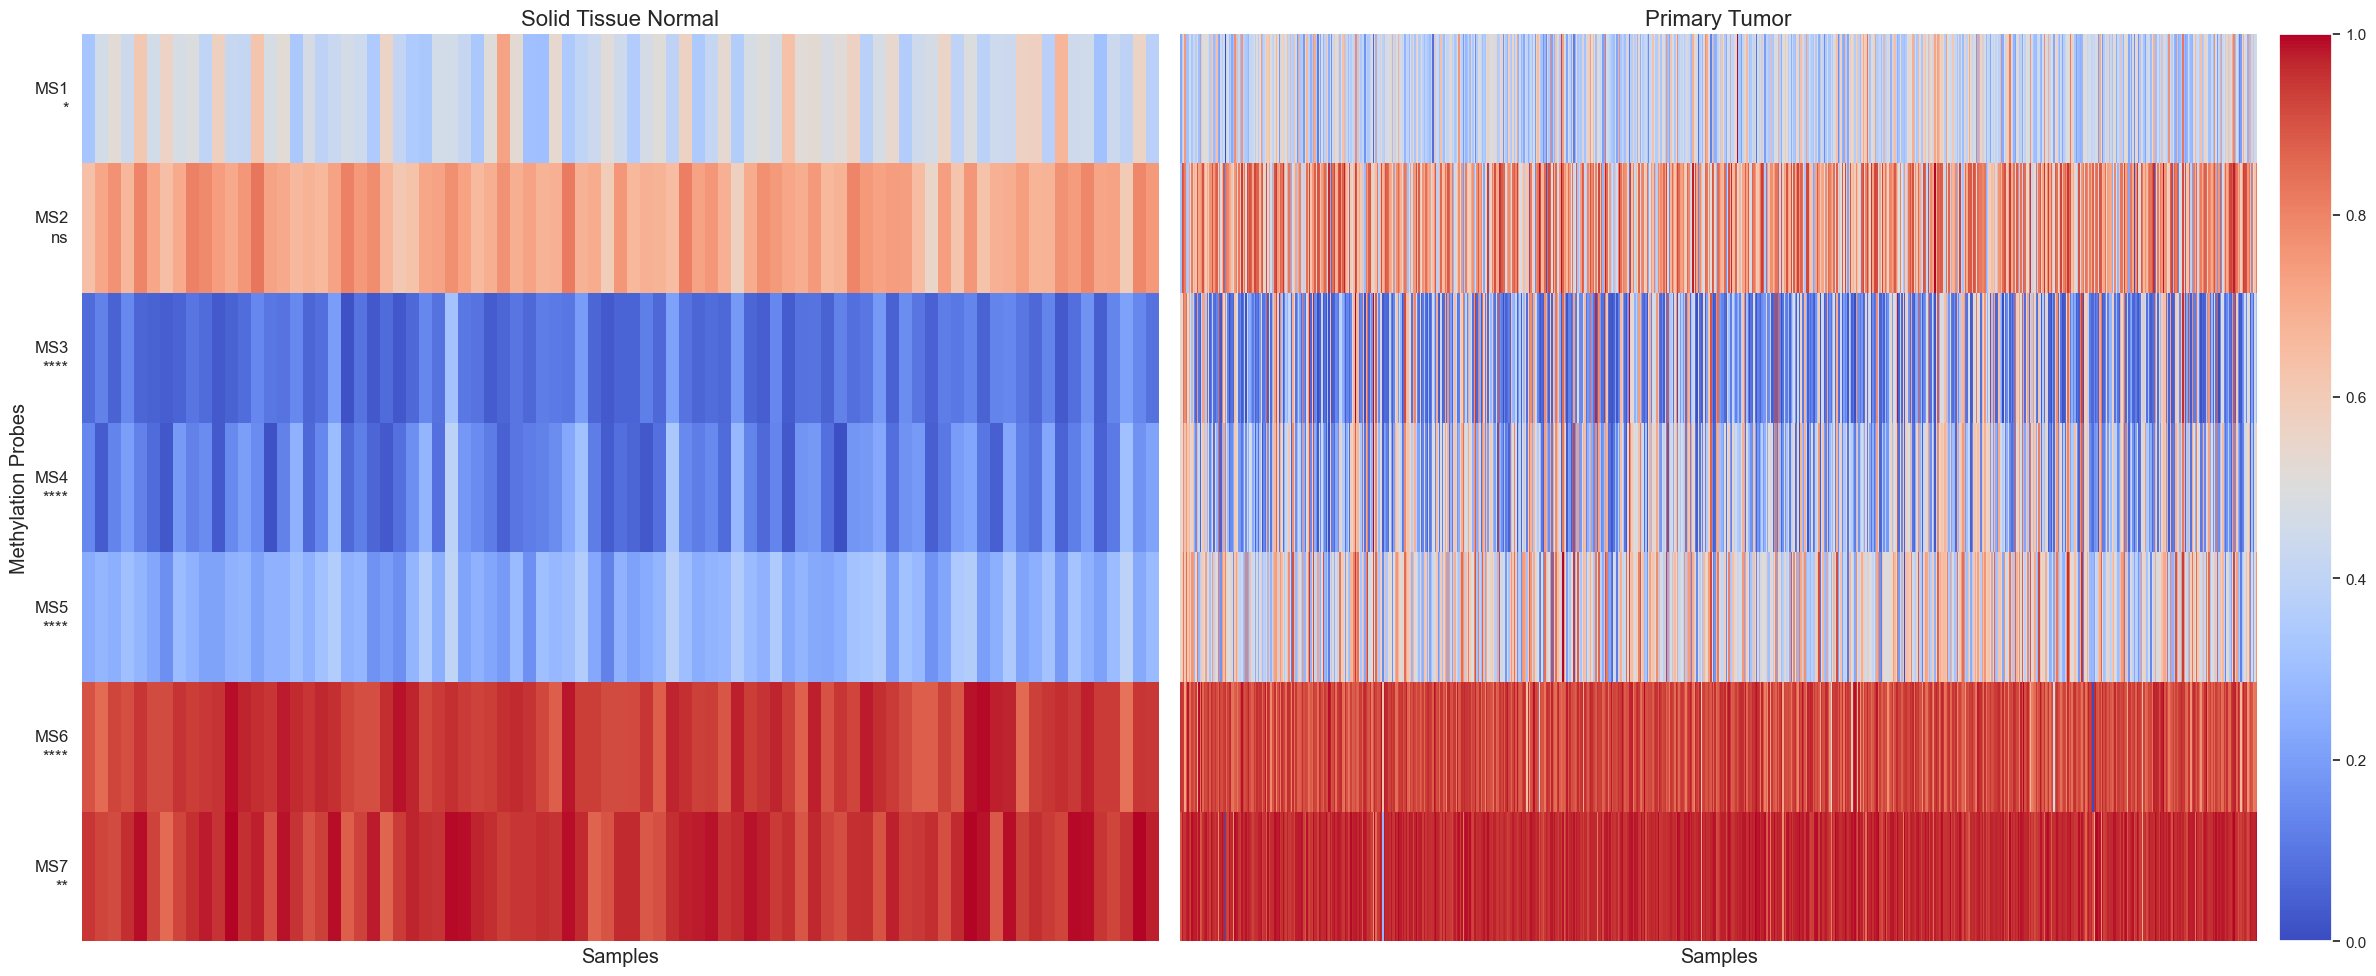


Statistical Test Results:
  Label       Probe       p-value       Test Used Significance
0   MS1  cg19257550  3.421860e-02  Mann-Whitney U            *
1   MS2  cg20610181  2.263710e-01  Mann-Whitney U           ns
2   MS3  cg06908460  4.318491e-12  Mann-Whitney U         ****
3   MS4  cg13849253  4.645775e-21  Mann-Whitney U         ****
4   MS5  cg09566069  1.796013e-30  Mann-Whitney U         ****
5   MS6  cg14563831  3.090803e-06  Mann-Whitney U         ****
6   MS7  cg13938361  3.334011e-03  Mann-Whitney U           **


In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset
df = pd.read_excel(r"C:\Users\jlapi\Desktop\XENA\BRCA\FINAL\BRCA_final_merged.xlsx")

# Define methylation probes and their labels
probe_label_map = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7"
}
methylation_probes = list(probe_label_map.keys())
ms_labels = list(probe_label_map.values())

# Filter and normalize (min-max scaling)
df = df[methylation_probes + ["sample_type.samples"]].dropna()
df[methylation_probes] = (
    (df[methylation_probes] - df[methylation_probes].min())
    / (df[methylation_probes].max() - df[methylation_probes].min())
)

# Split by sample type
df_tumor = df[df["sample_type.samples"] == "Primary Tumor"][methylation_probes]
df_normal = df[df["sample_type.samples"] == "Solid Tissue Normal"][methylation_probes]

# Statistical testing (Shapiro → T-test or Mann-Whitney U)
def test_probe(tumor_vals, normal_vals):
    p_shapiro_t = stats.shapiro(tumor_vals).pvalue
    p_shapiro_n = stats.shapiro(normal_vals).pvalue
    if p_shapiro_t > 0.05 and p_shapiro_n > 0.05:
        return "T-test", stats.ttest_ind(tumor_vals, normal_vals, equal_var=False).pvalue
    else:
        return "Mann-Whitney U", stats.mannwhitneyu(tumor_vals, normal_vals, alternative="two-sided").pvalue

stats_results = {
    probe: dict(zip(["test_used", "p_value"], test_probe(df_tumor[probe], df_normal[probe])))
    for probe in methylation_probes
}

def significance(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

# Y-axis labels with significance
ms_labels_with_sig = [
    f"{probe_label_map[p]}\n{significance(stats_results[p]['p_value'])}"
    for p in methylation_probes
]

# Build heatmap data per sample type
def build_heatmap_data(sample_type):
    return (
        df[df["sample_type.samples"] == sample_type][methylation_probes]
        .rename(columns=probe_label_map)
        .T
        .loc[ms_labels]
    )

sample_types = ["Solid Tissue Normal", "Primary Tumor"]
heatmap_data = {st: build_heatmap_data(st) for st in sample_types}

# Plot
sns.set(font_scale=1.2)
fig, axes = plt.subplots(
    1, 3, figsize=(24, 10),
    gridspec_kw={"width_ratios": [10, 10, 0.5]}
)

for i, (ax, sample_type) in enumerate(zip(axes[:2], sample_types)):
    is_first = i == 0
    sns.heatmap(
        heatmap_data[sample_type], cmap="coolwarm", linewidths=0,
        xticklabels=False, yticklabels=is_first,
        ax=ax, vmin=0.0, vmax=1.0, cbar=False,
    )
    ax.set_title(sample_type, fontsize=16)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Methylation Probes" if is_first else "")
    if is_first:
        ax.set_yticklabels(ms_labels_with_sig, rotation=0, fontsize=12, linespacing=1.4)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0.0, vmax=1.0))
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes[2], ticks=np.arange(0.0, 1.1, 0.2))
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Print statistical results
print("\nStatistical Test Results:")
print(pd.DataFrame([
    [probe_label_map[p], p, stats_results[p]["p_value"], stats_results[p]["test_used"], significance(stats_results[p]["p_value"])]
    for p in methylation_probes
], columns=["Label", "Probe", "p-value", "Test Used", "Significance"]))

In [ ]:
# Correlation between methylation and CA9 expression

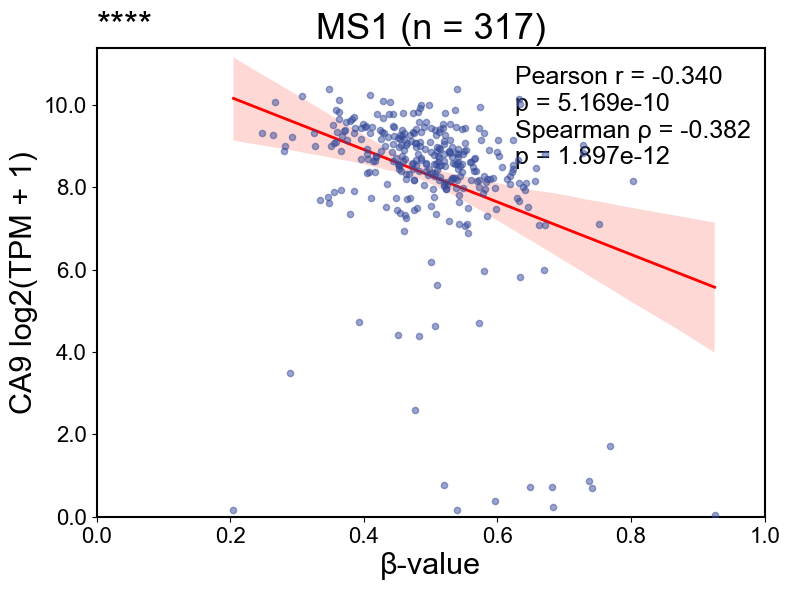

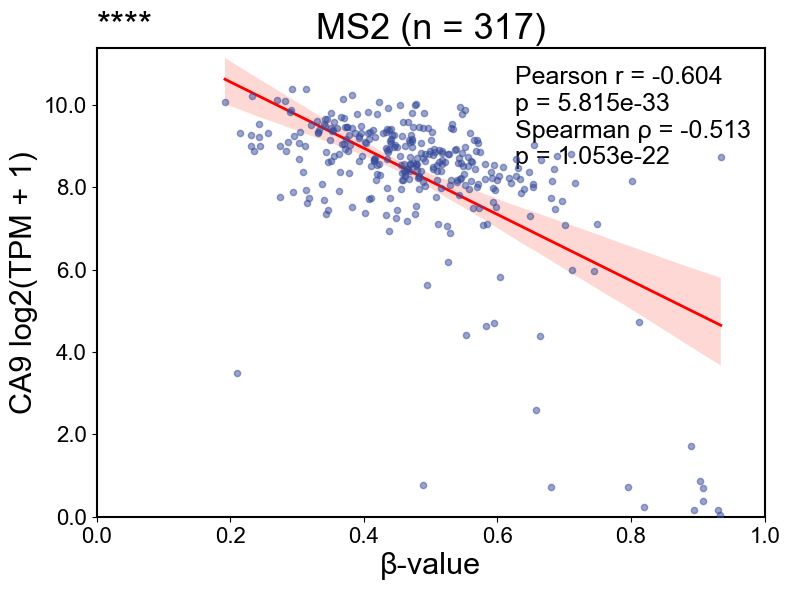

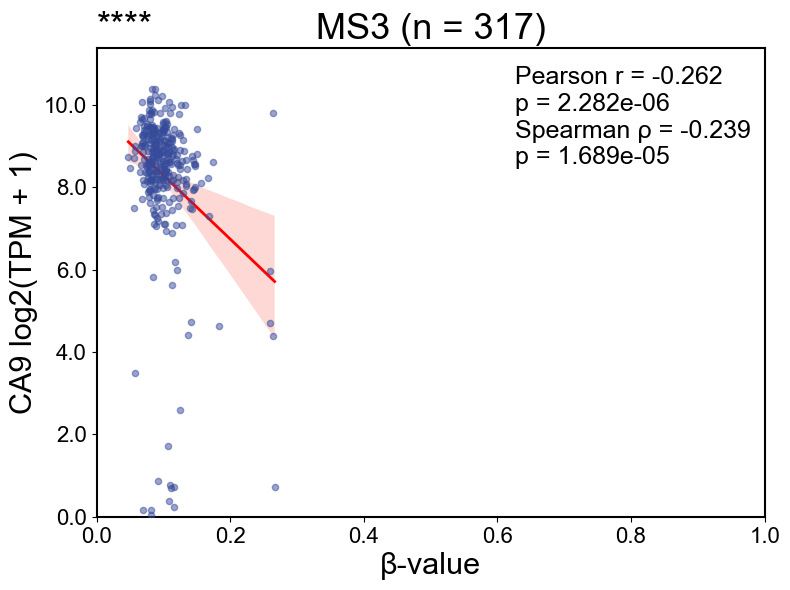

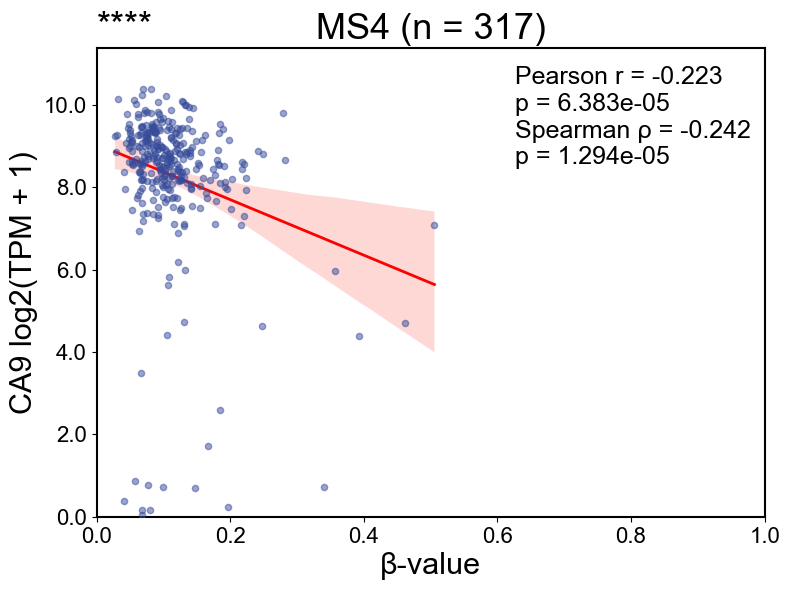

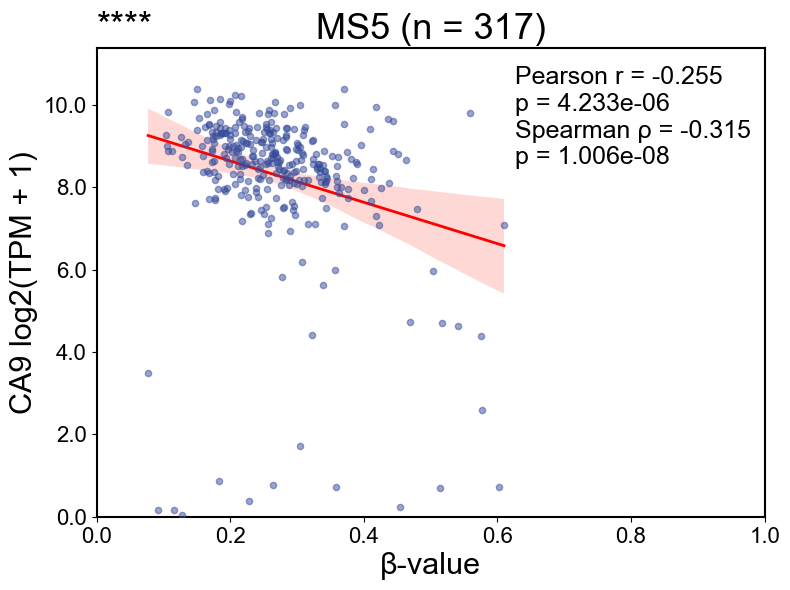

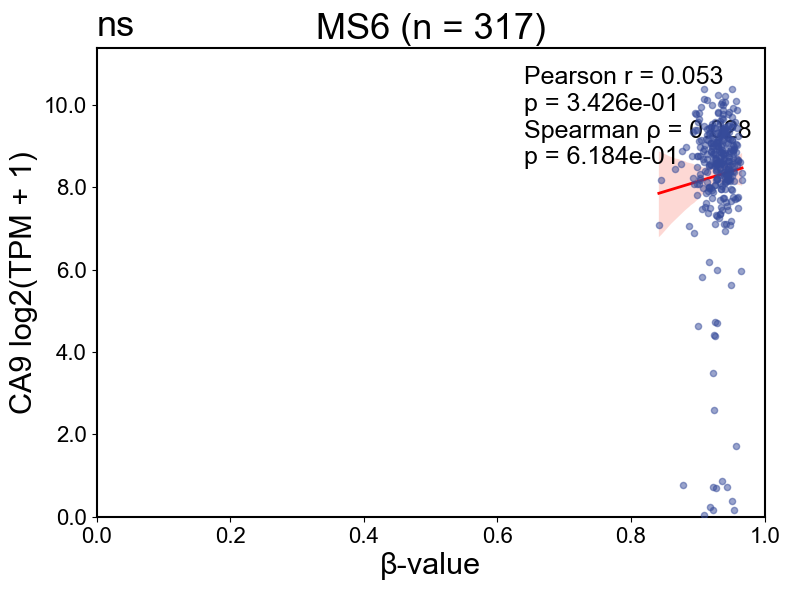

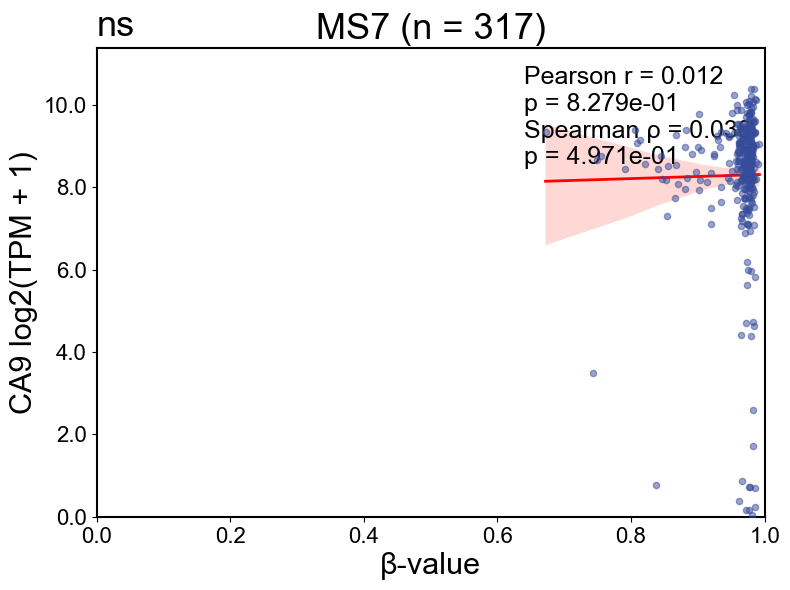

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams["font.family"] = "Arial"

file_path = r"C:\Users\jlapi\Desktop\KIRC_ComBat_corrected_final.xlsx"
df = pd.read_excel(file_path)

methylation_probes = [
    "cg19257550", "cg20610181", "cg06908460", "cg13849253",
    "cg09566069", "cg14563831", "cg13938361",
]

ms_labels = {probe: f"MS{i+1}" for i, probe in enumerate(methylation_probes)}

df_filtered = df[df["sample_type_samples"] == "Primary Tumor"]


def get_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


for probe in methylation_probes:
    ms_name = ms_labels[probe]

    df_probe = df_filtered[["CA9_Expression", probe]].dropna()
    n_patients = len(df_probe)

    corr, p_value_corr = stats.pearsonr(df_probe[probe], df_probe["CA9_Expression"])
    corr_spearman, p_value_spearman = stats.spearmanr(df_probe[probe], df_probe["CA9_Expression"])

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    sns.regplot(
        x=df_probe[probe],
        y=df_probe["CA9_Expression"],
        scatter=False,
        color="red",
        line_kws={"linewidth": 2},
        ci=95,
        ax=ax,
    )
    ax.collections[0].set_facecolor("salmon")
    ax.collections[0].set_alpha(0.3)

    ax.scatter(
        df_probe[probe], df_probe["CA9_Expression"],
        color="#364B9A", alpha=0.5, s=20, zorder=5,
    )

    ax.set_xlabel("β-value", fontsize=22)
    ax.set_ylabel("CA9 log2(TPM + 1)", fontsize=22)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, df_probe["CA9_Expression"].max() + 1)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))
    ax.set_title(f"{ms_name} (n = {n_patients})", fontsize=26)

    ax.text(
        0.0, 1.01, get_asterisks(p_value_spearman),
        fontsize=26, transform=ax.transAxes,
        va="bottom", ha="left",
    )

    ax.text(
        0.98, 0.96,
        f"Pearson r = {corr:.3f}\n"
        f"p = {p_value_corr:.3e}\n"
        f"Spearman ρ = {corr_spearman:.3f}\n"
        f"p = {p_value_spearman:.3e}",
        fontsize=18, transform=ax.transAxes,
        va="top", ha="right", multialignment="left",
    )

    ax.tick_params(labelsize=16, top=False, right=False)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# Summary figure of correlation between methylation sites and CA9 expression

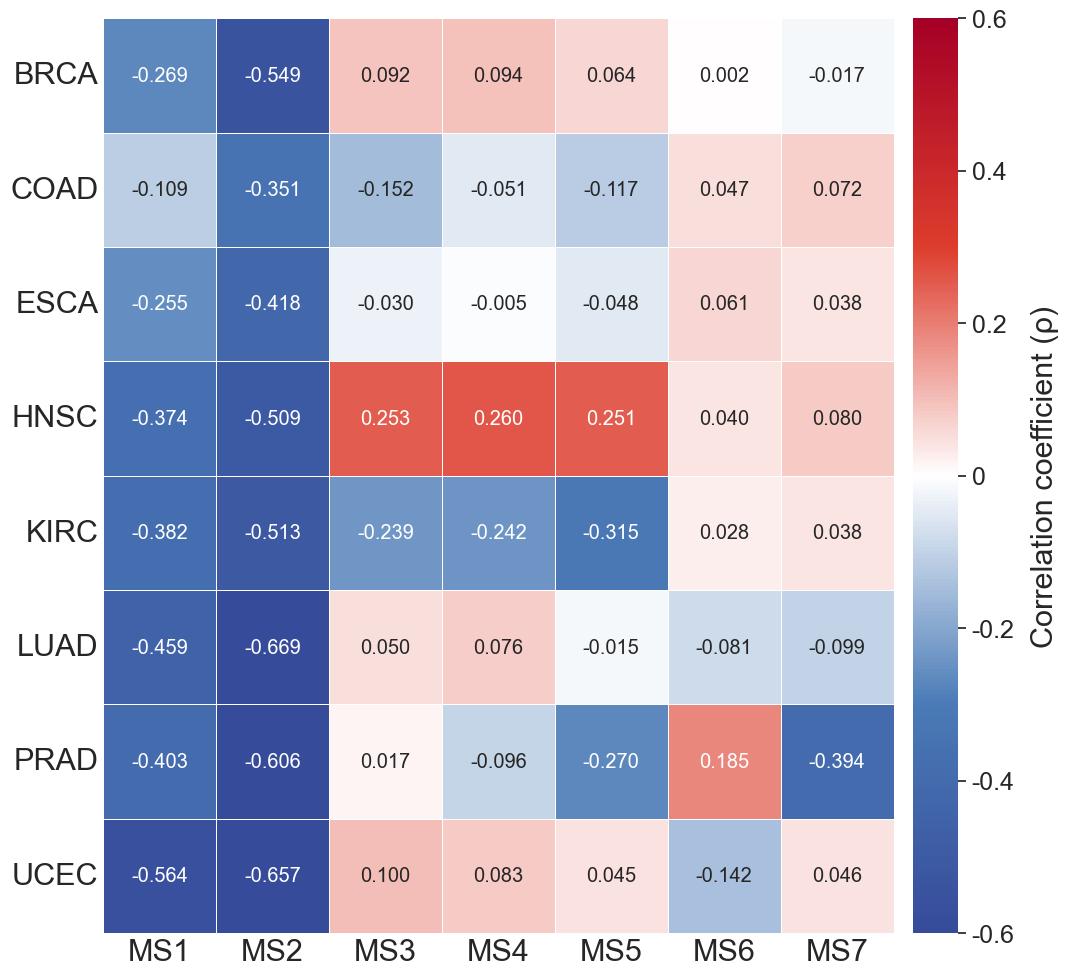

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
import seaborn as sns

# ── Configuration ─────────────────────────────────────────────────────────────
CANCER_TYPES = ["BRCA", "COAD", "ESCA", "HNSC", "KIRC", "LUAD", "PRAD", "UCEC"]

PROBES = [
    "cg19257550", "cg20610181", "cg06908460", "cg13849253",
    "cg09566069", "cg14563831", "cg13938361",
]
MS_LABELS = {probe: f"MS{i+1}" for i, probe in enumerate(PROBES)}

VMIN, VMAX = -0.6, 0.6

COLORMAP = LinearSegmentedColormap.from_list(
    "custom_div",
    ["#364B9A", "#4A7BB7", "white", "#DD3D2D", "#A50026"],
    N=256,
)


# ── Compute Spearman correlations ─────────────────────────────────────────────
records = []

for cancer in CANCER_TYPES:
    file_path = (
        f"C:/Users/jlapi/Desktop/XENA/{cancer}/FINAL/{cancer}_final_merged.xlsx"
    )
    df = pd.read_excel(file_path)
    df = df[df["sample_type.samples"] == "Primary Tumor"]

    row = {"Cancer_Type": cancer}
    for probe in PROBES:
        df_clean = df[["CA9_Expression", probe]].dropna()
        rho, _ = spearmanr(df_clean[probe], df_clean["CA9_Expression"])
        row[MS_LABELS[probe]] = round(rho, 3)
    records.append(row)

pivot = pd.DataFrame(records).set_index("Cancer_Type")
pivot.columns.name = "Site"


# ── Plot ──────────────────────────────────────────────────────────────────────
n_cancer, n_ms = pivot.shape
fig, ax = plt.subplots(
    figsize=(max(10, n_ms + 4), max(6, n_cancer + 2)),
    facecolor="white",
)

sns.heatmap(
    pivot,
    ax=ax,
    cmap=COLORMAP,
    vmin=VMIN,
    vmax=VMAX,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 1.0, "aspect": 20, "pad": 0.02},
)

cbar = ax.collections[0].colorbar
cbar.set_ticks([VMIN, -0.4, -0.2, 0, 0.2, 0.4, VMAX])
cbar.set_ticklabels(["-0.6", "-0.4", "-0.2", "0", "0.2", "0.4", "0.6"])
cbar.ax.tick_params(labelsize=18)
for label in cbar.ax.get_yticklabels():
    label.set_fontfamily("Arial")
cbar.ax.set_ylabel(
    "Correlation coefficient (ρ)", fontsize=22, fontfamily="Arial", labelpad=12
)
cbar.outline.set_linewidth(0)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=22, length=0)
ax.tick_params(axis="y", rotation=0, labelsize=22, length=0)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Arial")

plt.rcParams["font.family"] = "Arial"
plt.tight_layout()
plt.show()

In [ ]:
# Differences in methylation values according to the pathological stage

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


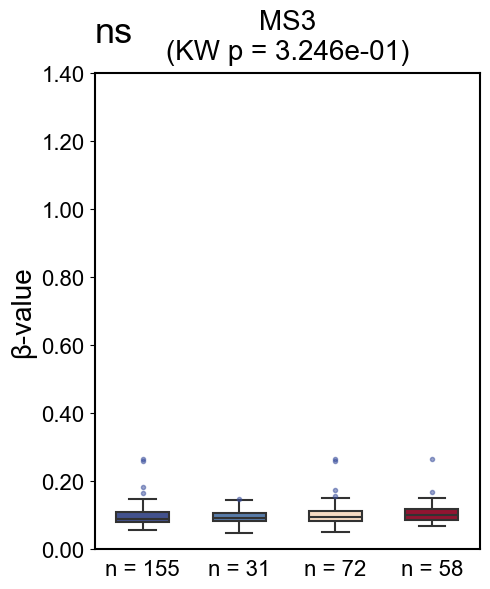

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


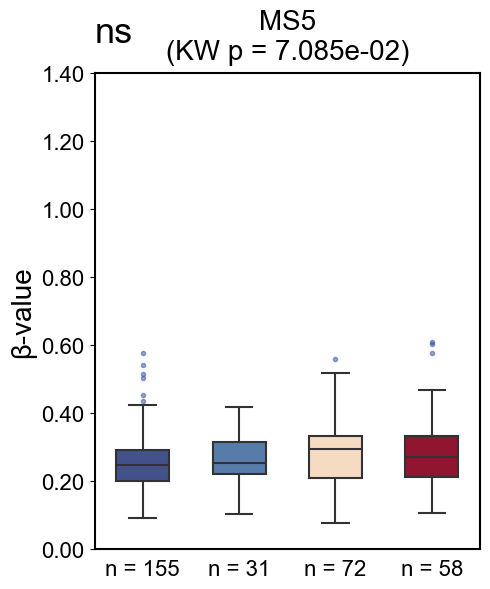

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


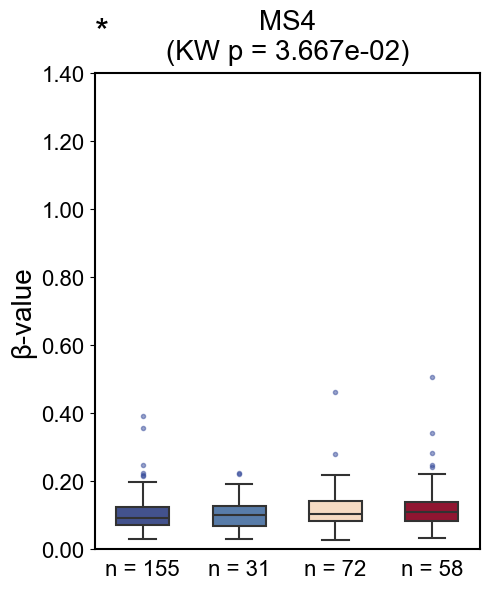

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


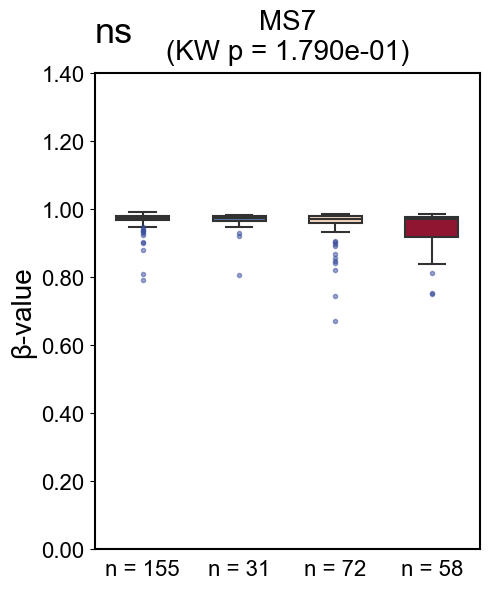

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


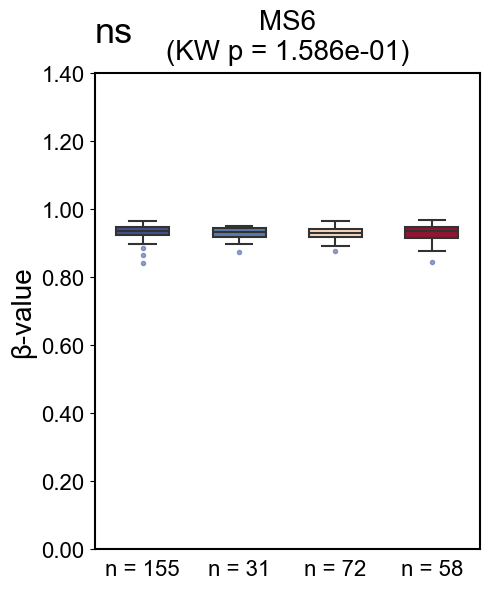

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


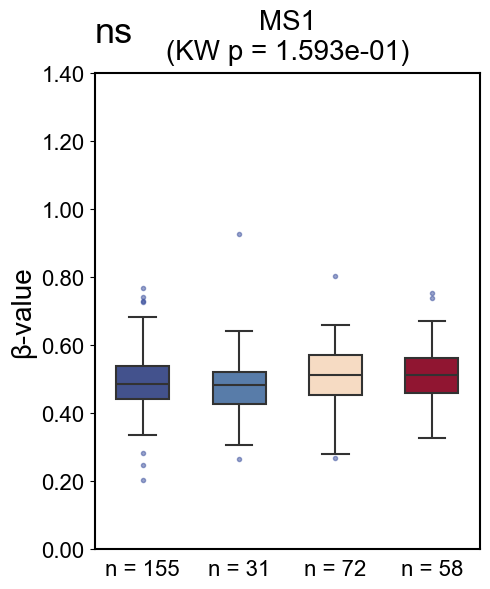

C:\Users\jlapi\AppData\Local\Temp\ipykernel_28988\1529797198.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


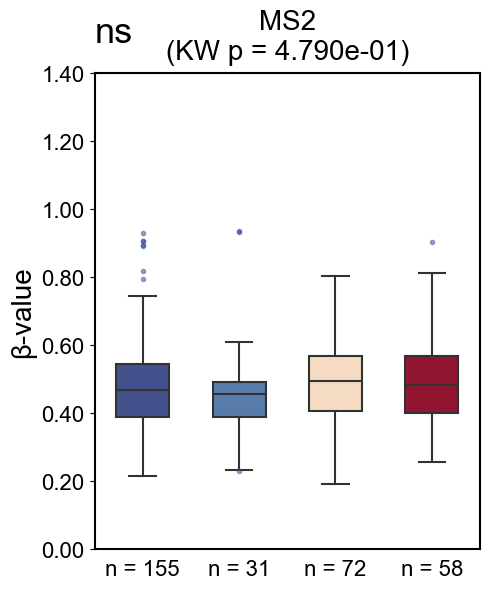

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams["font.family"] = "Arial"

# ── 1. LOAD & FILTER DATA ────────────────────────────────────────────────────
df = pd.read_excel(r"C:\Users\jlapi\Desktop\XENA\KIRC\FINAL\KIRC_final_merged.xlsx")
df = df[df["sample_type.samples"] != "Solid Tissue Normal"]

PROBES = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
]
PROBE_LABELS = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}
STAGE_PALETTE = {"I": "#364B9A", "II": "#4A7BB7", "III": "#FEDABB", "IV": "#A50026"}
STAGES = ["I", "II", "III", "IV"]

# ── 2. PREPARE STAGE COLUMN ──────────────────────────────────────────────────
def group_stage(stage):
    for s in ["IV", "III", "II", "I"]:
        if s in stage:
            return s
    return None

df = df[PROBES + ["ajcc_pathologic_stage.diagnoses"]].dropna()
df["stage"] = df["ajcc_pathologic_stage.diagnoses"].apply(group_stage)
df = df[df["stage"].isin(STAGES)]
df["stage"] = pd.Categorical(df["stage"], categories=STAGES, ordered=True)

# ── 3. STATISTICS ─────────────────────────────────────────────────────────────
def rank_biserial(x, y):
    U, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

def compute_stats(df, probe):
    groups = [df[df["stage"] == s][probe].values for s in STAGES]

    _, kw_p = stats.kruskal(*groups)

    pairs = [(STAGES[i], STAGES[j]) for i in range(4) for j in range(i + 1, 4)]
    p_raw = []
    for g1, g2 in pairs:
        x, y = df[df["stage"] == g1][probe], df[df["stage"] == g2][probe]
        _, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        p_raw.append(p)

    _, p_fdr, _, _ = multipletests(p_raw, alpha=0.05, method="fdr_bh")

    results = pd.DataFrame({
        "group1": [p[0] for p in pairs],
        "group2": [p[1] for p in pairs],
        "p_raw":  p_raw,
        "p_fdr":  p_fdr,
        "significant": p_fdr < 0.05,
    })
    return kw_p, results

# ── 4. PLOTTING HELPERS ───────────────────────────────────────────────────────
def stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

def bracket(ax, x1, x2, y, p, h=0.025):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, stars(p),
            ha="center", va="bottom", fontsize=13)

# ── 5. PLOT ───────────────────────────────────────────────────────────────────
for probe in PROBES:
    kw_p, results = compute_stats(df, probe)

    fig, ax = plt.subplots(figsize=(5, 6))

    sns.boxplot(
        data=df, x="stage", y=probe, order=STAGES,
        palette=STAGE_PALETTE, width=0.55, linewidth=1.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                        markerfacecolor="#364B9A", markeredgecolor="#364B9A"),
        legend=False, ax=ax,
    )

    y_top = df[probe].max()
    y_bracket = y_top + 0.03
    for _, row in results[results["significant"]].iterrows():
        x1, x2 = STAGES.index(row["group1"]), STAGES.index(row["group2"])
        bracket(ax, x1, x2, y_bracket, row["p_fdr"])
        y_bracket += 0.10

    ax.text(0.0, 1.05, stars(kw_p), fontsize=26, transform=ax.transAxes,
            va="bottom", ha="left")
    ax.set_title(f"{PROBE_LABELS[probe]}\n(KW p = {kw_p:.3e})", fontsize=20, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("β-value", fontsize=20)
    ax.set_ylim(0, max(y_bracket + 0.05, 1.40))
    ax.set_xlim(-0.5, len(STAGES) - 0.5)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

    n_labels = [f"n = {(df['stage'] == s).sum()}" for s in STAGES]
    ax.set_xticks(range(len(STAGES)))
    ax.set_xticklabels(n_labels, fontsize=16)
    ax.tick_params(labelsize=16, top=False, right=False, bottom=False)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

In [4]:
# Differences in methylation values according to the T-stage

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


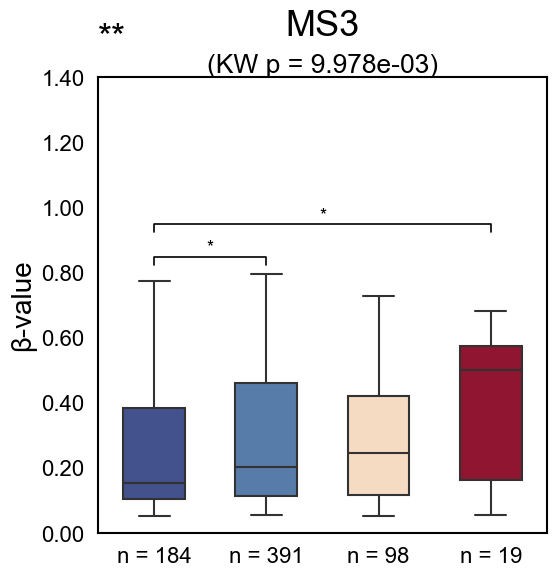

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


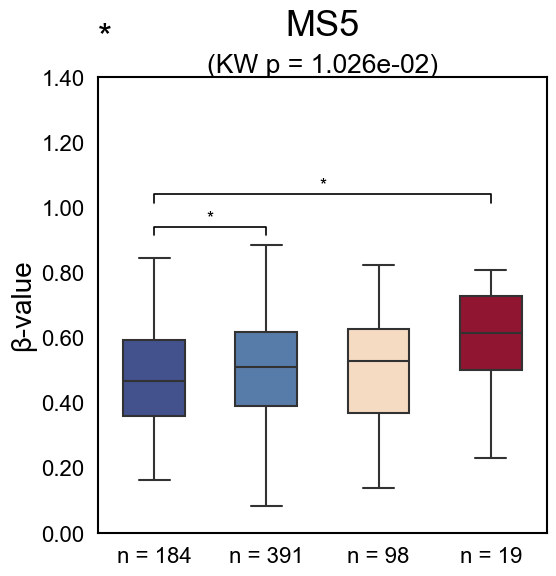

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


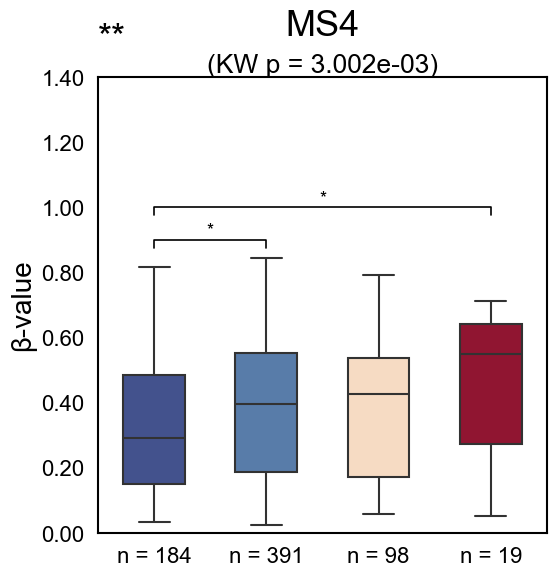

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


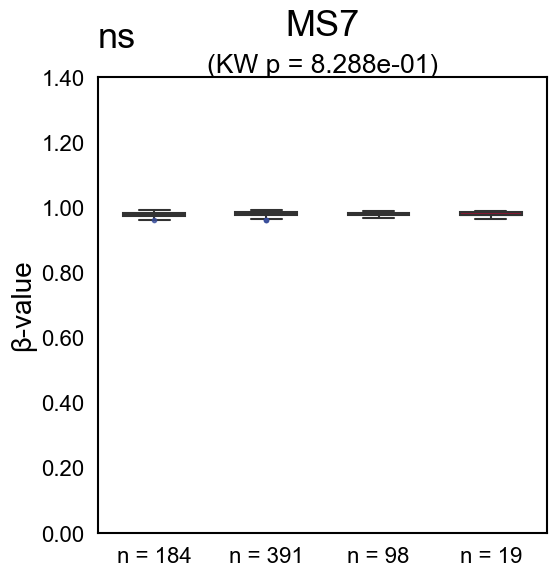

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


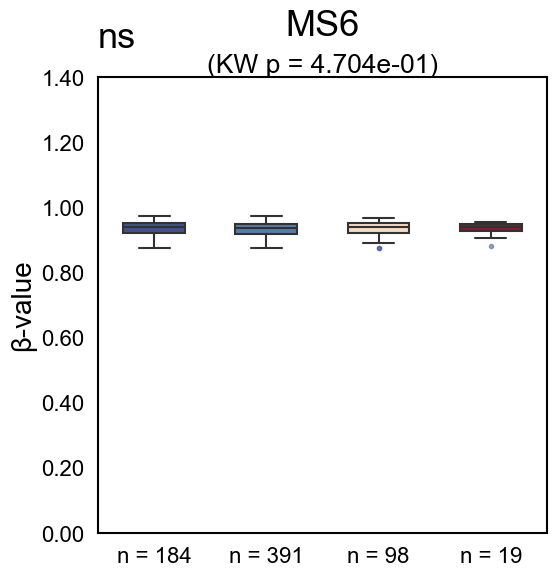

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


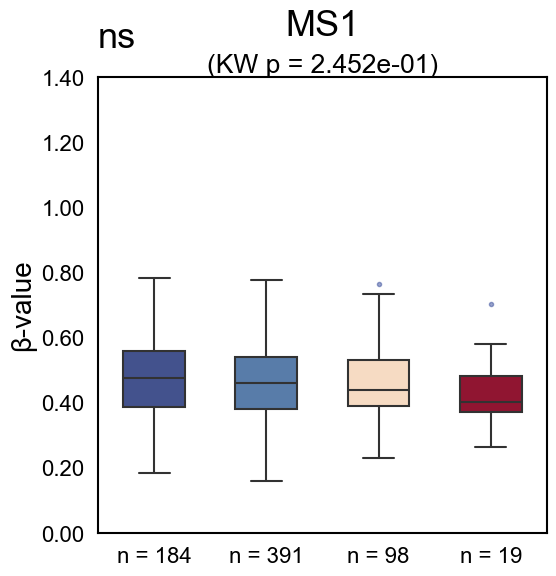

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\4127508819.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


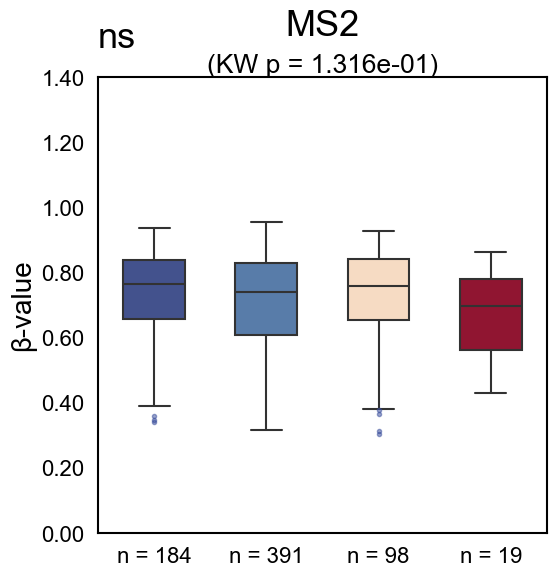

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams["font.family"] = "Arial"

# ── 1. LOAD & FILTER DATA ────────────────────────────────────────────────────
df = pd.read_excel(r"C:\Users\jlapi\Desktop\XENA\BRCA\FINAL\BRCA_final_merged.xlsx")
df = df[df["sample_type.samples"] == "Primary Tumor"].copy()

PROBES = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
]
MS_LABELS = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}
STAGES = ["T1", "T2", "T3", "T4"]
PALETTE = {"T1": "#364B9A", "T2": "#4A7BB7", "T3": "#FEDABB", "T4": "#A50026"}

df = df[PROBES + ["ajcc_pathologic_t.diagnoses"]].dropna()

# ── 2. GROUP T STAGES ────────────────────────────────────────────────────────
def group_t_stage(stage):
    for t in ["T1", "T2", "T3", "T4"]:
        if t in stage:
            return t
    return stage

df["T_stage"] = df["ajcc_pathologic_t.diagnoses"].apply(group_t_stage)

# ── 3. REMOVE OUTLIERS (IQR METHOD) ─────────────────────────────────────────
def remove_outliers_iqr(df, column):
    Q1, Q3 = df[column].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

for probe in PROBES:
    df = remove_outliers_iqr(df, probe)

df["T_stage"] = pd.Categorical(df["T_stage"], categories=STAGES, ordered=True)
valid_stages = [s for s in STAGES if s in df["T_stage"].unique()]

# ── 4. STATISTICAL TESTING ───────────────────────────────────────────────────
def rank_biserial(x, y):
    U, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

def compute_statistics(df, probe, stages):
    """Kruskal-Wallis + pairwise Mann-Whitney U with FDR correction."""
    groups = [df[df["T_stage"] == s][probe] for s in stages]
    kw_stat, kw_p = stats.kruskal(*groups)

    pairs, u_stats, p_vals, effect_sizes = [], [], [], []
    for i in range(len(stages)):
        for j in range(i + 1, len(stages)):
            g1, g2 = df[df["T_stage"] == stages[i]][probe], df[df["T_stage"] == stages[j]][probe]
            U, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            pairs.append((stages[i], stages[j]))
            u_stats.append(U)
            p_vals.append(p)
            effect_sizes.append(rank_biserial(g1, g2))

    reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method="fdr_bh")

    results = pd.DataFrame({
        "group1": [p[0] for p in pairs],
        "group2": [p[1] for p in pairs],
        "U_stat": u_stats,
        "p_raw": p_vals,
        "p_fdr": p_fdr,
        "significant": reject,
        "effect_size_rbc": effect_sizes,
        "KW_p": kw_p,
    })
    return kw_p, results

stats_results = {probe: compute_statistics(df, probe, valid_stages) for probe in PROBES}

# ── 5. PLOTTING HELPERS ──────────────────────────────────────────────────────
def p_to_stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

def add_bracket(ax, x1, x2, y, p, h=0.025):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, p_to_stars(p),
            ha="center", va="bottom", fontsize=13, color="black")

# ── 6. PLOT ──────────────────────────────────────────────────────────────────
for probe in PROBES:
    ms_name = MS_LABELS[probe]
    kw_p, results = stats_results[probe]

    fig, ax = plt.subplots(figsize=(1.2 + len(valid_stages) * 1.0 + 0.6, 6.0))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    sns.boxplot(
        data=df, x="T_stage", y=probe, order=valid_stages,
        palette=PALETTE, width=0.55, linewidth=1.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                        markerfacecolor="#364B9A", markeredgecolor="#364B9A"),
        legend=False, ax=ax,
    )

    # Significance brackets (FDR-significant pairs only)
    y_bracket = df[probe].max() + 0.03
    for _, row in results[results["significant"]].iterrows():
        x1, x2 = valid_stages.index(row["group1"]), valid_stages.index(row["group2"])
        add_bracket(ax, x1, x2, y_bracket, row["p_fdr"])
        y_bracket += 0.10

    # Labels & formatting
    ax.text(0.0, 1.05, p_to_stars(kw_p), fontsize=26, color="black",
            transform=ax.transAxes, va="bottom", ha="left")
    ax.set_title(ms_name, fontsize=26, color="black", pad=30)
    ax.text(0.5, 1.0, f"(KW p = {kw_p:.3e})", fontsize=19, color="black",
            transform=ax.transAxes, va="bottom", ha="center")

    ax.set_xlabel("")
    ax.set_ylabel("β-value", fontsize=20, color="black")
    ax.set_ylim(0, max(y_bracket + 0.05, 1.40))
    ax.set_xlim(-0.5, len(valid_stages) - 0.5)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

    n_labels = [f"n = {(df['T_stage'] == s).sum()}" for s in valid_stages]
    ax.set_xticks(range(len(valid_stages)))
    ax.set_xticklabels(n_labels, fontsize=19, color="black")
    ax.tick_params(colors="black", labelsize=16, top=False, right=False, bottom=False)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    ax.grid(False)
    plt.tight_layout()
    plt.show()

In [ ]:
# Differences in methylation values according to N-stage

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


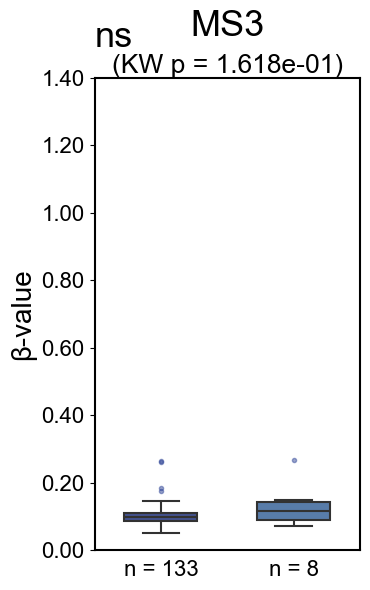

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


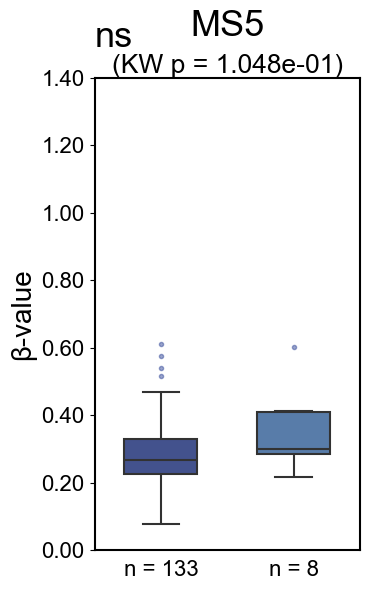

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


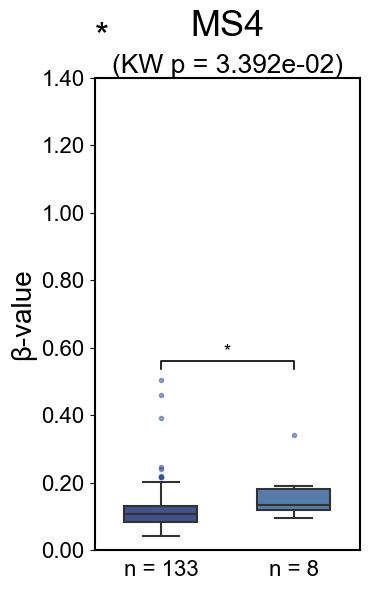

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


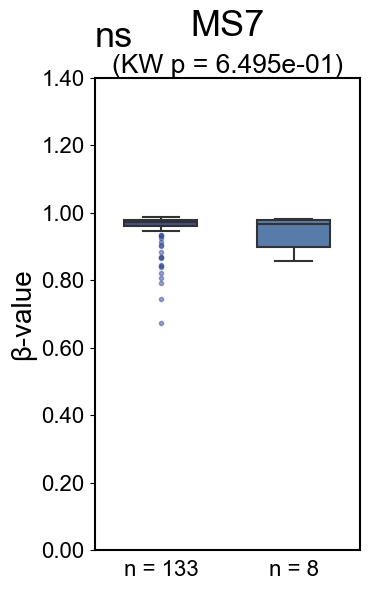

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


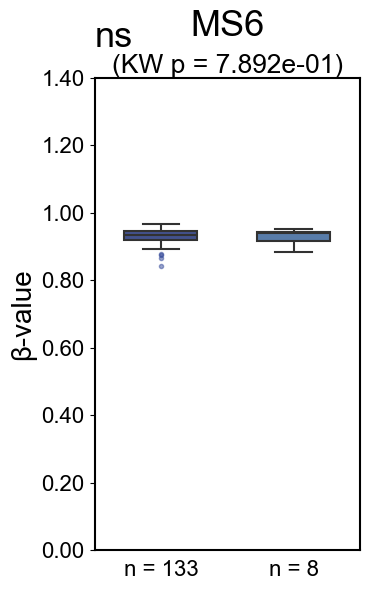

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


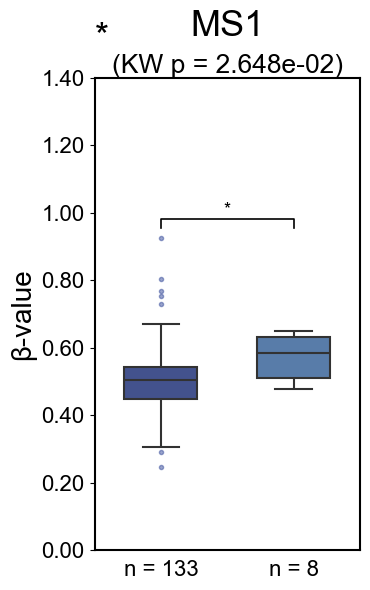

C:\Users\jlapi\AppData\Local\Temp\ipykernel_27044\4175613816.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


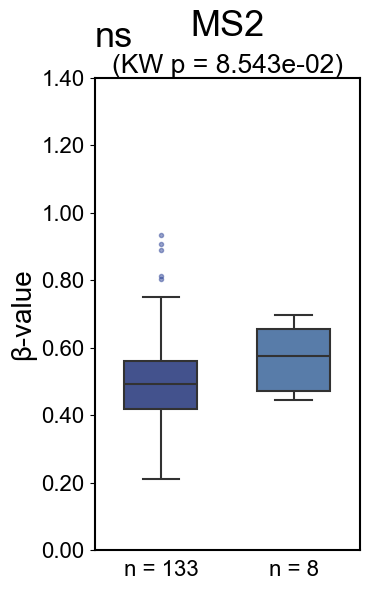

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams["font.family"] = "Arial"

# ── 1. LOAD & FILTER DATA ────────────────────────────────────────────────────
df = pd.read_excel(r"C:\Users\jlapi\Desktop\KIRC_ComBat_corrected_final.xlsx")
df = df[df["sample_type_samples"] == "Primary Tumor"].copy()

PROBES = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
]
MS_LABELS = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}
STAGES = ["N0", "N1", "N2", "N3"]
PALETTE = {"N0": "#364B9A", "N1": "#4A7BB7", "N2": "#FEDABB", "N3": "#A50026"}

df = df[PROBES + ["ajcc_pathologic_n_diagnoses"]].dropna()

# ── 2. GROUP N STAGES ────────────────────────────────────────────────────────
def group_n_stage(stage):
    stage = str(stage)
    for n in ["N0", "N1", "N2", "N3"]:
        if stage.startswith(n):
            return n
    return stage

df["N_stage"] = df["ajcc_pathologic_n_diagnoses"].apply(group_n_stage)
df["N_stage"] = pd.Categorical(df["N_stage"], categories=STAGES, ordered=True)
valid_stages = [s for s in STAGES if s in df["N_stage"].unique()]

# ── 3. STATISTICAL TESTING ───────────────────────────────────────────────────
def rank_biserial(x, y):
    U, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

def compute_statistics(df, probe, stages):
    """Kruskal-Wallis + pairwise Mann-Whitney U with FDR correction."""
    groups = [df[df["N_stage"] == s][probe] for s in stages]
    _, kw_p = stats.kruskal(*groups)

    pairs, u_stats, p_vals, effect_sizes = [], [], [], []
    for i in range(len(stages)):
        for j in range(i + 1, len(stages)):
            g1 = df[df["N_stage"] == stages[i]][probe]
            g2 = df[df["N_stage"] == stages[j]][probe]
            U, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            pairs.append((stages[i], stages[j]))
            u_stats.append(U)
            p_vals.append(p)
            effect_sizes.append(rank_biserial(g1, g2))

    reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method="fdr_bh")

    return kw_p, pd.DataFrame({
        "group1": [p[0] for p in pairs],
        "group2": [p[1] for p in pairs],
        "U_stat": u_stats,
        "p_raw": p_vals,
        "p_fdr": p_fdr,
        "significant": reject,
        "effect_size_rbc": effect_sizes,
        "KW_p": kw_p,
    })

stats_results = {probe: compute_statistics(df, probe, valid_stages) for probe in PROBES}

# ── 4. PLOTTING HELPERS ──────────────────────────────────────────────────────
def p_to_stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

def add_bracket(ax, x1, x2, y, p, h=0.025):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, p_to_stars(p),
            ha="center", va="bottom", fontsize=13, color="black")

# ── 5. PLOT ──────────────────────────────────────────────────────────────────
for probe in PROBES:
    ms_name = MS_LABELS[probe]
    kw_p, results = stats_results[probe]

    fig, ax = plt.subplots(figsize=(1.2 + len(valid_stages) * 1.0 + 0.6, 6.0))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    sns.boxplot(
        data=df, x="N_stage", y=probe, order=valid_stages,
        palette=PALETTE, width=0.55, linewidth=1.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                        markerfacecolor="#364B9A", markeredgecolor="#364B9A"),
        legend=False, ax=ax,
    )

    # Significance brackets (FDR-significant pairs only)
    y_bracket = df[probe].max() + 0.03
    for _, row in results[results["significant"]].iterrows():
        x1, x2 = valid_stages.index(row["group1"]), valid_stages.index(row["group2"])
        add_bracket(ax, x1, x2, y_bracket, row["p_fdr"])
        y_bracket += 0.10

    # Labels & formatting
    ax.text(0.0, 1.05, p_to_stars(kw_p), fontsize=26, color="black",
            transform=ax.transAxes, va="bottom", ha="left")
    ax.set_title(ms_name, fontsize=26, color="black", pad=30)
    ax.text(0.5, 1.0, f"(KW p = {kw_p:.3e})", fontsize=19, color="black",
            transform=ax.transAxes, va="bottom", ha="center")

    ax.set_xlabel("")
    ax.set_ylabel("β-value", fontsize=20, color="black")
    ax.set_ylim(0, max(y_bracket + 0.05, 1.40))
    ax.set_xlim(-0.5, len(valid_stages) - 0.5)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

    n_labels = [f"n = {(df['N_stage'] == s).sum()}" for s in valid_stages]
    ax.set_xticks(range(len(valid_stages)))
    ax.set_xticklabels(n_labels, fontsize=19, color="black")
    ax.tick_params(colors="black", labelsize=16, top=False, right=False, bottom=False)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    ax.grid(False)
    plt.tight_layout()
    plt.show()

In [ ]:
# Differences in methylation values according to the M-stage

           n_M0 n_M1  U_stat     p_raw     p_fdr effect_size_rbc direction
cg06908460  611   13  2527.0  0.024765  0.024765        0.363716       M1↑
cg09566069  611   13  2859.0  0.083832  0.083832        0.280121       M1↑
cg13849253  611   13  2578.0   0.03033   0.03033        0.350875       M1↑
cg13938361  611   13  3429.0  0.399413  0.399413        0.136598       M1↑
cg14563831  611   13  5317.0  0.036517  0.036517       -0.338789       M1↓
cg19257550  611   13  3270.0  0.275769  0.275769        0.176634       M1↑
cg20610181  611   13  5198.0  0.056635  0.056635       -0.308825       M1↓


C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


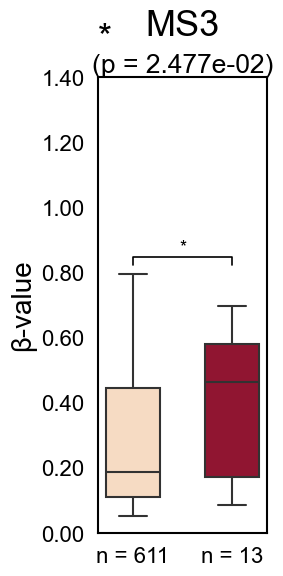

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


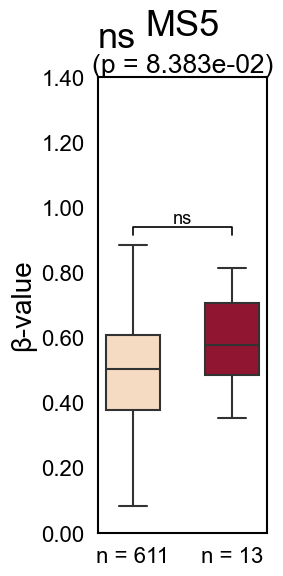

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


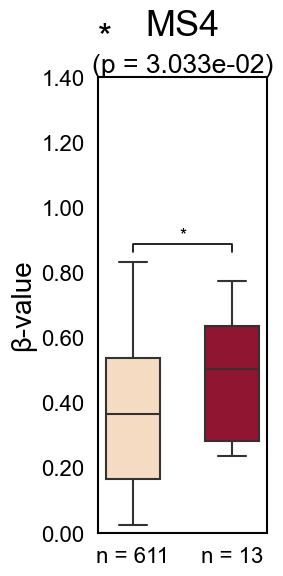

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


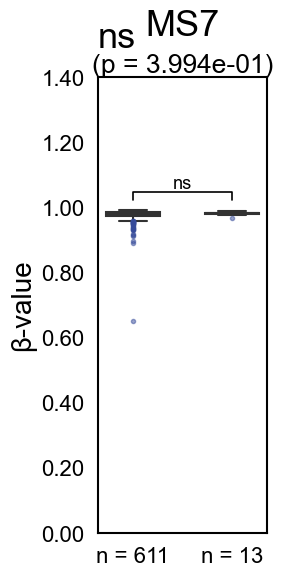

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


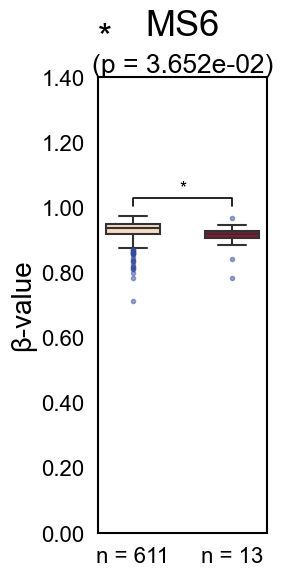

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


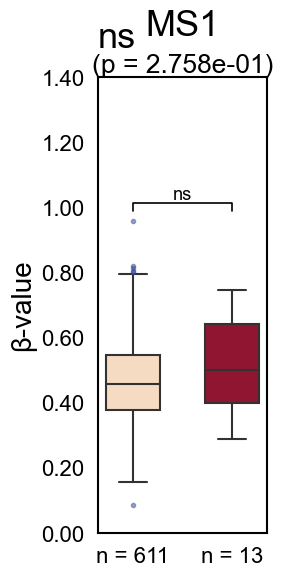

C:\Users\jlapi\AppData\Local\Temp\ipykernel_32928\3281002921.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


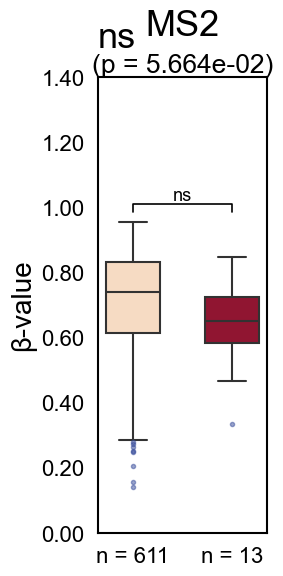

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── 1. LOAD & FILTER DATA ────────────────────────────────────────────────────
file_path = r"C:\Users\jlapi\Desktop\XENA\BRCA\FINAL\BRCA_final_merged.xlsx"
df = pd.read_excel(file_path)
df = df[df["sample_type.samples"] == "Primary Tumor"].copy()

methylation_probes = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
]

ms_labels = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}

df = df[methylation_probes + ["ajcc_pathologic_m.diagnoses"]].dropna()

# ── 2. CLASSIFY M STAGE ──────────────────────────────────────────────────────
def classify_m_stage(stage):
    stage = str(stage)
    if "M0" in stage:
        return "M0"
    elif "M1" in stage:
        return "M1"
    return None  # excludes MX from analysis

df["M_stage"] = df["ajcc_pathologic_m.diagnoses"].apply(classify_m_stage)
df = df[df["M_stage"].isin(["M0", "M1"])].copy()
df["M_stage"] = pd.Categorical(df["M_stage"], categories=["M0", "M1"], ordered=True)

# ── 3. STATISTICAL ANALYSIS (Mann–Whitney U + FDR correction) ────────────────
def rank_biserial(x, y):
    """Rank-biserial correlation as effect size for Mann–Whitney U test."""
    U, _ = stats.mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

results = {}

for probe in methylation_probes:
    m0 = df[df["M_stage"] == "M0"][probe]
    m1 = df[df["M_stage"] == "M1"][probe]

    U, p_raw = stats.mannwhitneyu(m0, m1, alternative="two-sided")
    rbc = rank_biserial(m0, m1)
    _, (p_fdr,), _, _ = multipletests([p_raw], alpha=0.05, method="fdr_bh")

    results[probe] = {
        "n_M0": len(m0), "n_M1": len(m1),
        "U_stat": U,
        "p_raw": p_raw, "p_fdr": p_fdr,
        "effect_size_rbc": rbc,
        "direction": "M1↑" if rbc > 0 else "M1↓",
    }

results_df = pd.DataFrame(results).T
print(results_df.to_string())

# ── 4. VISUALIZATION ─────────────────────────────────────────────────────────
PALETTE = {"M0": "#FEDABB", "M1": "#A50026"}

def significance_label(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

def add_bracket(ax, x1, x2, y, p, h=0.025):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, color="black")
    ax.text((x1 + x2) / 2, y + h, significance_label(p),
            ha="center", va="bottom", fontsize=13, color="black")

for probe in methylation_probes:
    ms_name = ms_labels[probe]
    res = results[probe]

    fig, ax = plt.subplots(figsize=(3.0, 6.0))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    sns.boxplot(
        data=df, x="M_stage", y=probe,
        order=["M0", "M1"], palette=PALETTE,
        width=0.55, linewidth=1.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.5,
                        markerfacecolor="#364B9A", markeredgecolor="#364B9A"),
        legend=False, ax=ax,
    )

    # Significance bracket (M0 vs M1) — always shown, stars reflect FDR p-value
    y_bracket = df[probe].max() + 0.03
    add_bracket(ax, 0, 1, y_bracket, res["p_fdr"])

    # KW equivalent label (only 2 groups → same as MW)
    ax.text(0.0, 1.05, significance_label(res["p_raw"]),
            fontsize=26, transform=ax.transAxes,
            va="bottom", ha="left", color="black")

    ax.set_title(ms_name, fontsize=26, pad=30, color="black")
    ax.text(0.5, 1.0, f"(p = {res['p_fdr']:.3e})",
            fontsize=19, transform=ax.transAxes,
            va="bottom", ha="center", color="black")

    ax.set_xlabel("")
    ax.set_ylabel("β-value", fontsize=20, color="black")
    ax.set_ylim(0, max(y_bracket + 0.15, 1.40))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f"n = {res['n_M0']}", f"n = {res['n_M1']}"],
        fontsize=19, color="black",
    )
    ax.tick_params(colors="black", labelsize=16,
                   top=False, right=False, bottom=False)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

In [ ]:
# Gaining all gene expression from datasets

In [44]:
import pandas as pd
import numpy as np
from scipy import stats

# ── Configuration ─────────────────────────────────────────────────────────────

genes = {
    "CA9":    "ENSG00000107159",
    "HIF1A":  "ENSG00000100644",
    "EPAS1":  "ENSG00000116016",
    "EGLN1":  "ENSG00000117594",
    "VHL":    "ENSG00000134086",
    "VEGFA":  "ENSG00000112715",
    "KDR":    "ENSG00000128052",
    "SLC2A1": "ENSG00000117394",
    "LDHA":   "ENSG00000134333",
    "PFKFB3": "ENSG00000142513",
    "TPI1":   "ENSG00000111669",
    "CPT1A":  "ENSG00000110090",
    "MTHFR":  "ENSG00000177000",
    "MYC":    "ENSG00000136997",
    "KRAS":   "ENSG00000133703",
    "BRAF":   "ENSG00000157764",
    "EGFR":   "ENSG00000146648",
    "ERBB2":  "ENSG00000141736",
    "MET":    "ENSG00000105976",
    "PIK3CA": "ENSG00000121879",
    "AKT1":   "ENSG00000142208",
    "MTOR":   "ENSG00000198793",
    "FOXM1":  "ENSG00000111206",
    "PTEN":   "ENSG00000171862",
    "STK11":  "ENSG00000118046",
    "TP53":   "ENSG00000141510",
    "RB1":    "ENSG00000139687",
    "CDKN1A": "ENSG00000124762",
    "CDKN2A": "ENSG00000147889",
    "CIC":    "ENSG00000079432",
    "BAP1":   "ENSG00000163930",
    "BRCA1":  "ENSG00000012048",
    "BRCA2":  "ENSG00000139618",
    "RAD51":  "ENSG00000051180",
    "ATM":    "ENSG00000149311",
    "FANCA":  "ENSG00000187741",
    "MLH1":   "ENSG00000076242",
    "MSH2":   "ENSG00000095002",
    "MSH6":   "ENSG00000116062",
    "BCL2":   "ENSG00000171791",
    "MCL1":   "ENSG00000143384",
    "BAX":    "ENSG00000087088",
    "BAD":    "ENSG00000002330",
    "CASP3":  "ENSG00000164305",
    "CASP8":  "ENSG00000064012",
    "DNMT1":  "ENSG00000130816",
    "DNMT3A": "ENSG00000119772",
    "DNMT3B": "ENSG00000088305",
    "DNMT3L": "ENSG00000142182",
    "EZH2":   "ENSG00000106462",
    "HDAC1":  "ENSG00000116478",
    "HDAC2":  "ENSG00000196591",
    "HDAC3":  "ENSG00000171720",
    "TET1":   "ENSG00000138336",
    "TET2":   "ENSG00000168769",
    "TET3":   "ENSG00000187605",
    "TDG":    "ENSG00000139372",
    "PBRM1":  "ENSG00000163171",
    "SETD2":  "ENSG00000181555",
    "KDM5C":  "ENSG00000126012",
    "TTN":    "ENSG00000155657",
    "NFE2L2": "ENSG00000116044",
    "CYP1A1": "ENSG00000140505",
    "APC":    "ENSG00000134982",
    "GSK3B":  "ENSG00000082701",
    "CTNNB1": "ENSG00000168036",
    "TGFB1":  "ENSG00000105329",
    "SNAI1":  "ENSG00000185591",
    "SNAI2":  "ENSG00000019549",
    "NOTCH1": "ENSG00000148400",
    "TWIST1": "ENSG00000122691",
    "VIM":    "ENSG00000026025",
    "CDH1":   "ENSG00000039068",
    "CDH2":   "ENSG00000170558",
    "CFL1":   "ENSG00000172757",
    "MMP9":   "ENSG00000100985",
    "CD274":  "ENSG00000120217",
    "PDCD1":  "ENSG00000188389",
    "CTLA4":  "ENSG00000163599",
    "AR":     "ENSG00000169083",
    "ERG":    "ENSG00000157554",
}

meth_sites = [
    "cg06908460", "cg09566069", "cg13849253", "cg13938361",
    "cg14563831", "cg19257550", "cg20610181",
]

tpm_path   = r"C:\Users\jlapi\Desktop\XENA\KIRC\TCGA-KIRC.star_tpm.tsv"
main_path  = r"C:\Users\jlapi\Desktop\XENA\KIRC\FINAL\KIRC_final_merged.xlsx"
corr_out   = r"C:\Users\jlapi\Desktop\KIRC_Gene_Methylation_Correlations.xlsx"

# ── Step 1: Load TPM, filter genes, transpose ─────────────────────────────────

ensembl_to_gene = {v: k for k, v in genes.items()}

df_tpm = pd.read_csv(tpm_path, sep="\t", low_memory=False)
df_tpm.rename(columns={df_tpm.columns[0]: "Ensembl_ID"}, inplace=True)
df_tpm["Ensembl_ID"] = df_tpm["Ensembl_ID"].str.split(".").str[0]
df_tpm = df_tpm[df_tpm["Ensembl_ID"].isin(ensembl_to_gene)]

df_tpm = (
    df_tpm.set_index("Ensembl_ID")
    .T
    .rename(columns=ensembl_to_gene)
)
df_tpm.index.name = "sample"

print(f"TPM: {df_tpm.shape[0]} samples, {df_tpm.shape[1]} genes")

# ── Step 2: Load main file and merge ──────────────────────────────────────────

df_main = pd.read_excel(main_path)

# Rename first column to "sample" if needed
if df_main.columns[0] != "sample":
    df_main.rename(columns={df_main.columns[0]: "sample"}, inplace=True)

df_merged = pd.merge(df_main, df_tpm, on="sample", how="inner")
print(f"Merged: {df_merged.shape[0]} samples, {df_merged.shape[1]} columns")

# ── Step 3: Pearson correlations → pivot table (genes × meth sites) ───────────

genes_present = [g for g in genes if g in df_merged.columns]
meth_present  = [m for m in meth_sites if m in df_merged.columns]

print(f"Genes found: {len(genes_present)} / {len(genes)}")
print(f"Meth sites found: {len(meth_present)} / {len(meth_sites)}")

records = []
for gene in genes_present:
    for meth in meth_present:
        pair = df_merged[[gene, meth]].dropna()
        if len(pair) >= 3:
            r, p = stats.pearsonr(pair[gene], pair[meth])
        else:
            r, p = np.nan, np.nan
        records.append({"Gene": gene, "Methylation_Site": meth, "r": r, "p": p})

results_df = pd.DataFrame(records)

# Pivot: rows = genes, columns = methylation sites (matching your Excel layout)
pivot_r = results_df.pivot(index="Gene", columns="Methylation_Site", values="r")
pivot_p = results_df.pivot(index="Gene", columns="Methylation_Site", values="p")

# Preserve gene order as defined in the genes dict
pivot_r = pivot_r.reindex(index=genes_present, columns=meth_present)
pivot_p = pivot_p.reindex(index=genes_present, columns=meth_present)

# ── Step 4: Save ──────────────────────────────────────────────────────────────

with pd.ExcelWriter(corr_out, engine="openpyxl") as writer:
    pivot_r.to_excel(writer, sheet_name="Pearson_r")
    pivot_p.to_excel(writer, sheet_name="P_value")
    results_df.to_excel(writer, sheet_name="All_Pairs", index=False)

print(f"Saved → {corr_out}")

TPM: 610 samples, 81 genes
Merged: 342 samples, 183 columns
Genes found: 81 / 81
Meth sites found: 7 / 7
Saved → C:\Users\jlapi\Desktop\KIRC_Gene_Methylation_Correlations.xlsx


In [ ]:
# Correlation with HIF1alpha

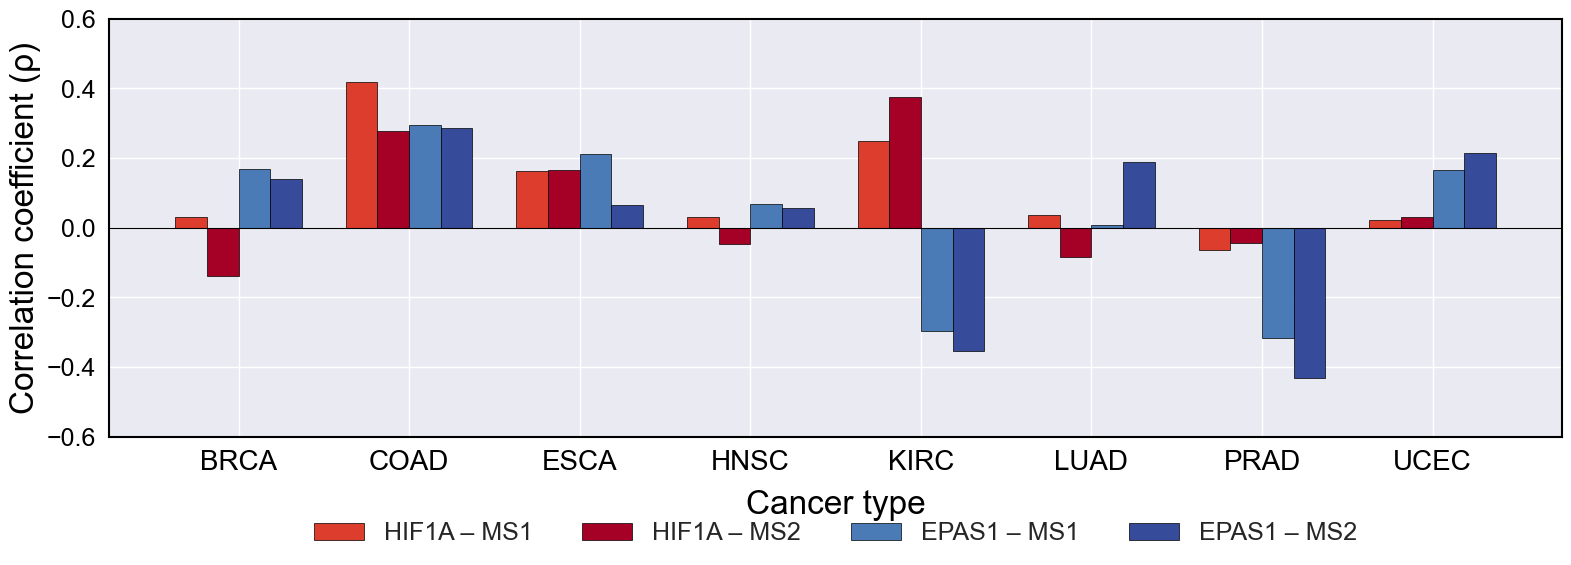

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# =============================
# Formatting
# =============================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.major.width"] = 1.5
plt.rcParams["ytick.major.width"] = 1.5

# =============================
# Definitions
# =============================
cancer_types = ["BRCA", "COAD", "ESCA", "HNSC", "KIRC", "LUAD", "PRAD", "UCEC"]
distal_sites = ["cg19257550", "cg20610181"]

base_path = r"C:\Users\jlapi\Desktop\KIRC_Gene_Methylation_Correlations2.xlsx"

# =============================
# Helper functions
# =============================


def parse_correlation(value):
    """Extract correlation coefficient and significance level from cell."""
    if pd.isna(value) or value == "":
        return np.nan, 0
    value_str = str(value).strip()
    corr = float(value_str.split()[0])
    if "***" in value_str:
        sig = 3
    elif "**" in value_str:
        sig = 2
    elif "*" in value_str:
        sig = 1
    else:
        sig = 0
    return corr, sig


def load_all_data():
    all_data = {}
    for cancer in cancer_types:
        file_path = base_path.replace("KIRC", cancer)
        try:
            df = pd.read_excel(file_path)
            df = df.set_index(df.columns[0])
            all_data[cancer] = df
        except Exception as e:
            print(f"Error loading {cancer}: {e}")
    return all_data


def extract_gene_data(all_data, gene):
    results = {}
    for cancer in cancer_types:
        if cancer not in all_data:
            continue
        df = all_data[cancer]
        if gene not in df.index:
            continue
        gene_row = df.loc[gene]
        results[cancer] = {}
        for cpg in distal_sites:
            if cpg in gene_row.index:
                corr, sig = parse_correlation(gene_row[cpg])
                results[cancer][cpg] = {"corr": corr, "sig": sig}
    return results


def add_significance(ax, x, y, sig):
    stars = {3: "***", 2: "**", 1: "*"}
    if sig in stars:
        offset = 0.02 if y >= 0 else -0.04
        ax.text(x, y + offset, stars[sig], ha="center", fontsize=13)


def get_values(data, cpg, key):
    return [data.get(c, {}).get(cpg, {}).get(key, 0 if key == "sig" else np.nan)
            for c in cancer_types]


# =============================
# Load & extract data
# =============================
all_data = load_all_data()
hif1a_data = extract_gene_data(all_data, "HIF1A")
epas1_data = extract_gene_data(all_data, "EPAS1")

# =============================
# Plot
# =============================
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(cancer_types)) * 1.4
bar_width = 0.26

bar_groups = [
    (x - bar_width,       hif1a_data, "cg19257550", "#DD3D2D", "HIF1A – MS1"),
    (x,                   hif1a_data, "cg20610181", "#A50026", "HIF1A – MS2"),
    (x + bar_width,       epas1_data, "cg19257550", "#4A7BB7", "EPAS1 – MS1"),
    (x + 2 * bar_width,   epas1_data, "cg20610181", "#364B9A", "EPAS1 – MS2"),
]

for positions, data, cpg, color, label in bar_groups:
    corrs = get_values(data, cpg, "corr")
    sigs  = get_values(data, cpg, "sig")
    bars = ax.bar(positions, corrs, bar_width,
                  color=color, edgecolor="black", linewidth=0.5, label=label)
    for bar, sig, corr in zip(bars, sigs, corrs):
        if sig > 0 and not np.isnan(corr):
            add_significance(ax, bar.get_x() + bar.get_width() / 2, corr, sig)

# ---- Formatting ----
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Correlation coefficient (ρ)", fontsize=24, color="black")
ax.set_xlabel("Cancer type", fontsize=24, color="black", labelpad=10)
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(cancer_types, rotation=0, ha="center", fontsize=20, color="black")
ax.tick_params(colors="black", labelsize=20, top=False, right=False)
ax.yaxis.set_tick_params(labelsize=18)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks(np.arange(-0.6, 0.61, 0.2))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

ax.legend(frameon=False, fontsize=18, ncol=4,
          loc="upper center", bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()

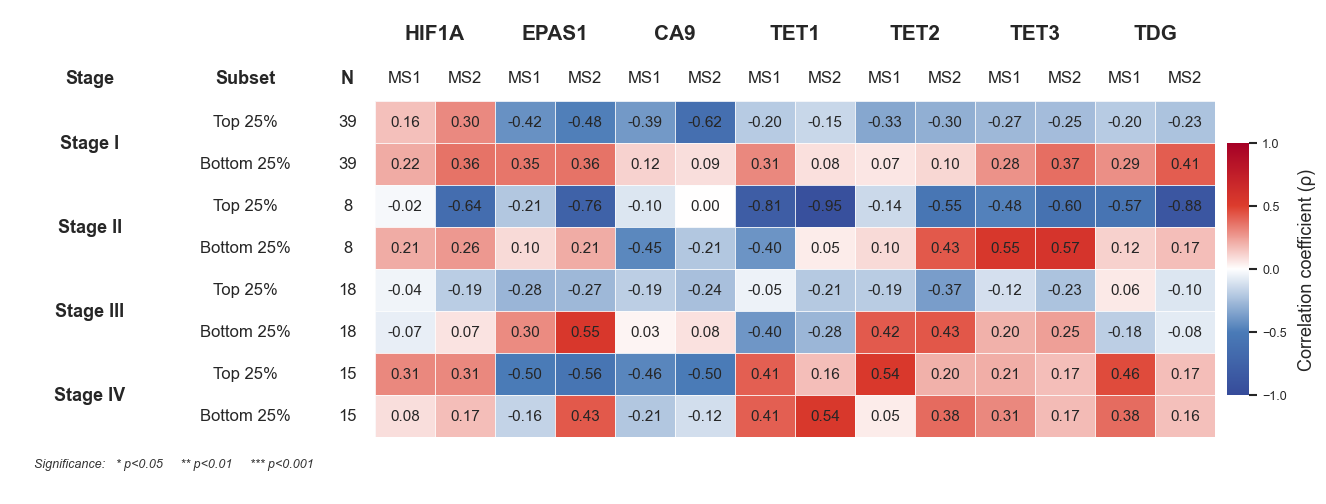

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# ── Configuration ─────────────────────────────────────────────────────────────

TPM_PATH    = r"C:\Users\jlapi\Desktop\XENA\KIRC\TCGA-KIRC.star_tpm.tsv"
MAIN_PATH   = r"C:\Users\jlapi\Desktop\KIRC_final_with_HIF.xlsx"

STAGE_ORDER   = ["Stage I", "Stage II", "Stage III", "Stage IV"]
SUBSET_ORDER  = ["top25", "bottom25"]
SUBSET_LABELS = {"top25": "Top 25%", "bottom25": "Bottom 25%"}
GENE_ORDER    = ["HIF1A", "EPAS1", "CA9_Expression", "TET1", "TET2", "TET3", "TDG"]
GENE_LABELS   = {
    "HIF1A": "HIF1A", "EPAS1": "EPAS1", "CA9_Expression": "CA9",
    "TET1": "TET1",   "TET2": "TET2",   "TET3": "TET3",   "TDG": "TDG",
}
ENSEMBL_MAP = {
    "ENSG00000138336": "TET1",
    "ENSG00000168769": "TET2",
    "ENSG00000187605": "TET3",
    "ENSG00000139372": "TDG",
}
CPG_SITES   = ["cg19257550", "cg20610181"]
CPG_RENAME  = {"cg19257550": "MS1", "cg20610181": "MS2"}
SIG_LEVELS  = [(0.001, "***"), (0.01, "**"), (0.05, "*")]

PALETTE_HEX = ["#364B9A", "#4A7BB7", "white", "#DD3D2D", "#A50026"]
CUSTOM_CMAP = LinearSegmentedColormap.from_list("custom_RdBu", PALETTE_HEX, N=512)
norm        = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# ── Step 1: Load and extract TET/TDG expression from TPM file ─────────────────

tpm = pd.read_csv(TPM_PATH, sep="\t", encoding="utf-8", low_memory=False)
tpm = tpm.rename(columns={tpm.columns[0]: "Ensembl_ID"})
tpm["Ensembl_ID"] = tpm["Ensembl_ID"].str.split(".").str[0]
tpm = tpm[tpm["Ensembl_ID"].isin(ENSEMBL_MAP.keys())]
tpm = tpm.set_index("Ensembl_ID").T
tpm = tpm[list(ENSEMBL_MAP.keys())]
tpm.columns = [ENSEMBL_MAP[c] for c in tpm.columns]
tpm.index.name = "sample"
tpm = tpm.reset_index()

# ── Step 2: Merge with main dataset ───────────────────────────────────────────

df_main   = pd.read_excel(MAIN_PATH)
df        = pd.merge(df_main, tpm, on="sample", how="inner")
df        = df[df["sample_type.samples"] == "Primary Tumor"]

# ── Step 3: Compute Spearman correlations ─────────────────────────────────────

records = []

for stage in STAGE_ORDER:
    df_stage = df[df["ajcc_pathologic_stage.diagnoses"] == stage]
    for cpg in CPG_SITES:
        q75 = df_stage[cpg].quantile(0.75)
        q25 = df_stage[cpg].quantile(0.25)
        subsets = {
            "top25":    df_stage[df_stage[cpg] >= q75],
            "bottom25": df_stage[df_stage[cpg] <= q25],
        }
        for subset_name, subset_df in subsets.items():
            for gene in GENE_ORDER:
                clean = subset_df[[cpg, gene]].dropna()
                if len(clean) < 5:
                    continue
                r, p = spearmanr(clean[cpg], clean[gene])
                records.append({
                    "Stage": stage, "CpG": cpg, "Subset": subset_name,
                    "Gene": gene, "N": len(clean),
                    "Spearman_r": round(r, 4),
                    "Spearman_p": round(p, 4),
                })

results = pd.DataFrame(records)

# ── Step 4: Build matrices for the heatmap ────────────────────────────────────

n_subsets = len(SUBSET_ORDER)
n_genes   = len(GENE_ORDER)
n_cpg     = len(CPG_SITES)
n_rows    = len(STAGE_ORDER) * n_subsets
n_cols    = n_genes * n_cpg

r_matrix   = np.full((n_rows, n_cols), np.nan)
txt_matrix = [[""] * n_cols for _ in range(n_rows)]
n_matrix   = {}

for s_idx, stage in enumerate(STAGE_ORDER):
    for sub_idx, subset in enumerate(SUBSET_ORDER):
        row_i  = s_idx * n_subsets + sub_idx
        sample = results[(results["Stage"] == stage) & (results["Subset"] == subset)]
        n_matrix[(s_idx, sub_idx)] = (
            int(sample["N"].iloc[0]) if not sample.empty else ""
        )
        for g_idx, gene in enumerate(GENE_ORDER):
            for m_idx, cpg in enumerate(CPG_SITES):
                col_i = g_idx * n_cpg + m_idx
                match = results[
                    (results["Stage"]  == stage)  &
                    (results["Subset"] == subset) &
                    (results["Gene"]   == gene)   &
                    (results["CpG"]    == cpg)
                ]
                if not match.empty:
                    r_val = match["Spearman_r"].values[0]
                    r_matrix[row_i, col_i]   = r_val
                    txt_matrix[row_i][col_i] = f"{r_val:.2f}"

# ── Step 5: Draw the figure ───────────────────────────────────────────────────

def r_to_rgba(r):
    if np.isnan(r):
        return mcolors.to_rgba("white")
    return CUSTOM_CMAP(norm(float(np.clip(r, -1.0, 1.0))))

CELL_W   = 0.60;  CELL_H   = 0.42
STAGE_W  = 1.60;  SUBSET_W = 1.50;  N_W = 0.55
LEFT_W   = STAGE_W + SUBSET_W + N_W
GENEH_H  = 0.50;  MSH_H    = 0.42;  LEGEND_H = 0.45

heat_w = n_cols * CELL_W
heat_h = n_rows * CELL_H
fig_w  = LEFT_W + heat_w + 0.85
fig_h  = GENEH_H + MSH_H + heat_h + LEGEND_H + 0.25

fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")

def make_ax(left_in, top_in, w_in, h_in):
    return fig.add_axes([
        left_in / fig_w,
        (fig_h - top_in - h_in) / fig_h,
        w_in / fig_w,
        h_in / fig_h,
    ])

def hide_ax(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

y0 = 0.0
y1 = GENEH_H
y2 = GENEH_H + MSH_H
y3 = y2 + heat_h + 0.12

# Gene-name header
ax_gene = make_ax(LEFT_W, y0, heat_w, GENEH_H)
ax_gene.set_facecolor("white")
ax_gene.set_xlim(0, n_cols); ax_gene.set_ylim(0, 1)
hide_ax(ax_gene)
for g_idx, gene in enumerate(GENE_ORDER):
    ax_gene.text(
        g_idx * n_cpg + n_cpg / 2, 0.5, GENE_LABELS[gene],
        ha="center", va="center",
        fontsize=15, fontweight="bold", fontfamily="Arial",
    )

# MS1/MS2 sub-header
ax_ms_side = make_ax(0, y1, LEFT_W, MSH_H)
ax_ms_side.set_facecolor("white")
ax_ms_side.set_xlim(0, 1); ax_ms_side.set_ylim(0, 1)
hide_ax(ax_ms_side)
for label, xpos in [
    ("Stage",  (STAGE_W / 2) / LEFT_W),
    ("Subset", (STAGE_W + SUBSET_W / 2) / LEFT_W),
    ("N",      (STAGE_W + SUBSET_W + N_W / 2) / LEFT_W),
]:
    ax_ms_side.text(
        xpos, 0.55, label,
        transform=ax_ms_side.transAxes,
        ha="center", va="center",
        fontsize=13, fontweight="bold", fontfamily="Arial",
    )

ax_ms = make_ax(LEFT_W, y1, heat_w, MSH_H)
ax_ms.set_facecolor("white")
ax_ms.set_xlim(0, n_cols); ax_ms.set_ylim(0, 1)
hide_ax(ax_ms)
for col_i, label in enumerate([CPG_RENAME[c] for c in CPG_SITES] * n_genes):
    ax_ms.text(
        col_i + 0.5, 0.55, label,
        ha="center", va="center",
        fontsize=12, fontfamily="Arial",
    )

# Sidebar (Stage / Subset / N)
ax_side = make_ax(0, y2, LEFT_W, heat_h)
ax_side.set_facecolor("white")
ax_side.set_xlim(0, LEFT_W); ax_side.set_ylim(0, n_rows)
ax_side.invert_yaxis()
hide_ax(ax_side)
for s_idx, stage in enumerate(STAGE_ORDER):
    ax_side.text(
        STAGE_W / 2, s_idx * n_subsets + n_subsets / 2, stage,
        ha="center", va="center",
        fontsize=13, fontweight="bold", fontfamily="Arial",
    )
    for sub_idx, subset in enumerate(SUBSET_ORDER):
        row_i    = s_idx * n_subsets + sub_idx
        y_center = row_i + 0.5
        ax_side.text(
            STAGE_W + SUBSET_W / 2, y_center, SUBSET_LABELS[subset],
            ha="center", va="center", fontsize=12, fontfamily="Arial",
        )
        ax_side.text(
            STAGE_W + SUBSET_W + N_W / 2, y_center,
            str(n_matrix.get((s_idx, sub_idx), "")),
            ha="center", va="center", fontsize=12, fontfamily="Arial",
        )

# Heatmap
ax_heat = make_ax(LEFT_W, y2, heat_w, heat_h)
ax_heat.set_xlim(0, n_cols); ax_heat.set_ylim(n_rows, 0)
hide_ax(ax_heat)
for i in range(n_rows):
    for j in range(n_cols):
        ax_heat.add_patch(plt.Rectangle(
            (j, i), 1, 1,
            facecolor=r_to_rgba(r_matrix[i, j]),
            edgecolor="white", linewidth=0.5,
        ))
        if txt_matrix[i][j]:
            ax_heat.text(
                j + 0.5, i + 0.5, txt_matrix[i][j],
                ha="center", va="center",
                fontsize=11, fontfamily="Arial",
            )

# Colour bar
cbar_h   = heat_h * 0.75
cbar_top = y2 + (heat_h - cbar_h) / 2
ax_cbar  = make_ax(LEFT_W + heat_w + 0.12, cbar_top, 0.22, cbar_h)
sm = plt.cm.ScalarMappable(cmap=CUSTOM_CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Correlation coefficient (ρ)", fontsize=13, fontfamily="Arial", labelpad=8)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0)
cbar.set_ticks([-1.0, -0.5, 0, 0.5, 1.0])

# Significance legend
ax_leg = make_ax(0, y3, LEFT_W + heat_w, LEGEND_H)
ax_leg.set_facecolor("white"); ax_leg.axis("off")
ax_leg.text(
    0.02, 0.6,
    "Significance:   * p<0.05     ** p<0.01     *** p<0.001",
    transform=ax_leg.transAxes,
    fontsize=9, fontstyle="italic", fontfamily="Arial", color="#333333",
)

plt.show()

In [ ]:
# Correlation between methylation and immune checkpoint gene expression

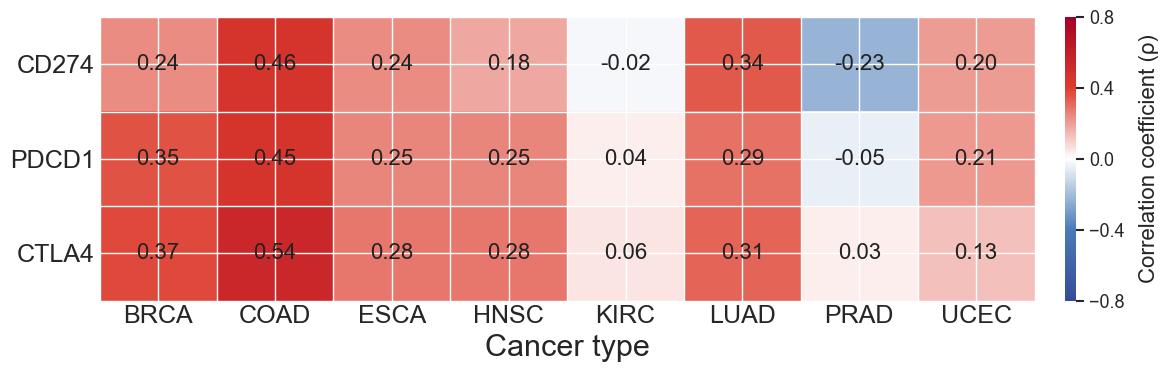

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# =============================
# Configuration
# =============================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

cancer_types = ['BRCA', 'COAD', 'ESCA', 'HNSC', 'KIRC', 'LUAD', 'PRAD', 'UCEC']
immune_genes = ['CD274', 'PDCD1', 'CTLA4']
base_path = r"C:\Users\jlapi\Desktop\KIRC_Gene_Methylation_Correlations2.xlsx"

VMIN, VCENTER, VMAX = -0.8, 0, 0.8

COLORMAP = LinearSegmentedColormap.from_list(
    "custom", ["#364B9A", "#4A7BB7", "white", "#DD3D2D", "#A50026"]
)

# =============================
# Helper functions
# =============================
def parse_correlation(value):
    if pd.isna(value) or value == '':
        return np.nan, 0
    s = str(value).strip()
    corr = float(s.split()[0])
    sig = 3 if '***' in s else 2 if '**' in s else 1 if '*' in s else 0
    return corr, sig

def load_all_data():
    return {
        cancer: pd.read_excel(base_path.replace('KIRC', cancer)).pipe(
            lambda df: df.set_index(df.columns[0])
        )
        for cancer in cancer_types
    }

# =============================
# Load & build matrices
# =============================
data = load_all_data()

heatmap = np.zeros((len(immune_genes), len(cancer_types)))
sigmap  = np.zeros_like(heatmap)

for i, gene in enumerate(immune_genes):
    for j, cancer in enumerate(cancer_types):
        heatmap[i, j], sigmap[i, j] = parse_correlation(
            data[cancer].loc[gene, 'cg19257550']
        )

# =============================
# Plot
# =============================
fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')

im = ax.imshow(
    heatmap,
    cmap=COLORMAP,
    norm=TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX),
    aspect='auto',
    interpolation='none',
)

# Cell annotations
for i in range(len(immune_genes)):
    for j in range(len(cancer_types)):
        label = f"{heatmap[i, j]:.2f}" + '*' * int(sigmap[i, j])
        ax.text(j, i, label, ha='center', va='center', fontsize=16, color='#222222')

# Grid
ax.set_xticks(np.arange(-0.5, len(cancer_types), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(immune_genes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.0)
ax.tick_params(which='minor', length=0)

# Axis labels
ax.set_xticks(range(len(cancer_types)))
ax.set_xticklabels(cancer_types, rotation=0, ha='center', fontsize=18)
ax.set_yticks(range(len(immune_genes)))
ax.set_yticklabels(immune_genes, fontsize=18)
ax.tick_params(axis='both', which='major', length=0)
ax.set_xlabel('Cancer type', fontsize=22)

for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, aspect=25)
cbar.set_label('Correlation coefficient (ρ)', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=13)
cbar.set_ticks([-0.8, -0.4, 0, 0.4, 0.8])
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Heatmap showing the mean correlation coefficients between CA9 methylation sites and epigenetic regulators 

Loading data...
  Loaded: ['BRCA', 'COAD', 'ESCA', 'LUAD', 'PRAD']
Computing mean...
Plotting...


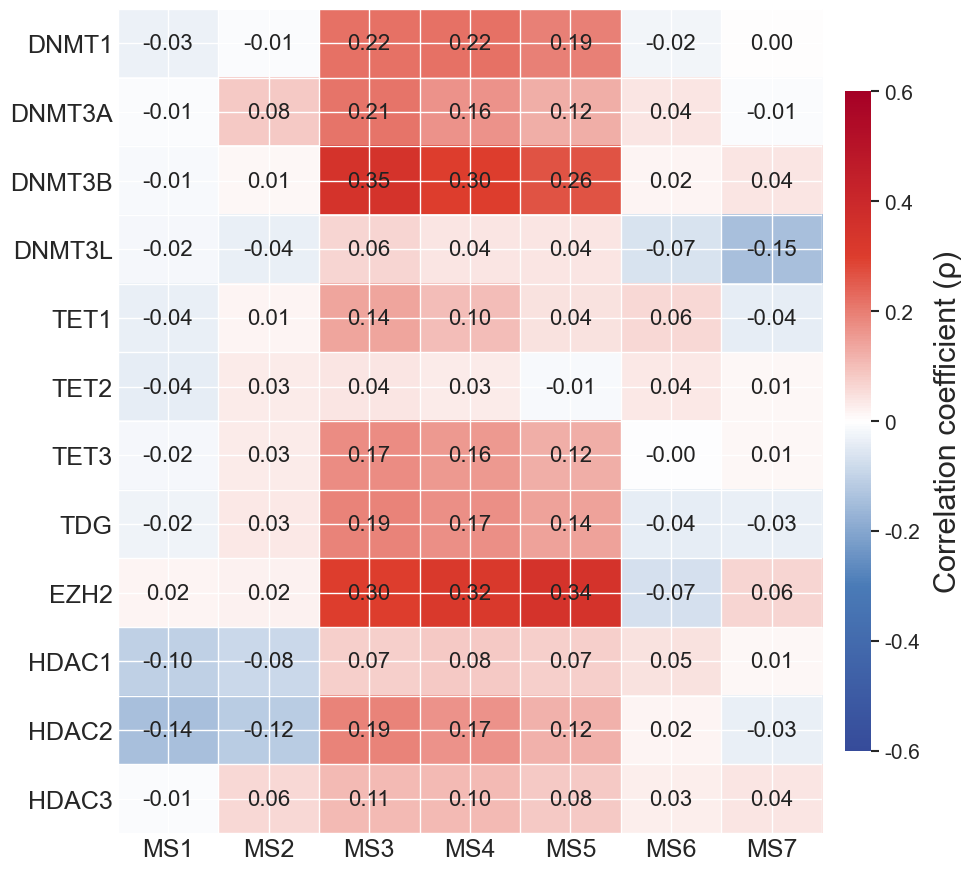

In [29]:
#Figure 9D
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ── Configuration ─────────────────────────────────────────────────────────────
FILE_DIR = r"C:\Users\jlapi\Desktop"
FILE_SUFFIX = "_Gene_Methylation_Correlations2.xlsx"

CANCER_TYPES = ["BRCA", "COAD", "ESCA", "LUAD", "PRAD"]
GENES_OF_INTEREST = [
    "DNMT1", "DNMT3A", "DNMT3B", "DNMT3L",
    "TET1", "TET2", "TET3", "TDG",
    "EZH2", "HDAC1", "HDAC2", "HDAC3",
]
PROBE_TO_MS = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}
MS_ORDER = ["MS1", "MS2", "MS3", "MS4", "MS5", "MS6", "MS7"]
VMIN, VCENTER, VMAX = -0.6, 0, 0.6

COLORMAP = LinearSegmentedColormap.from_list("custom", [
    "#364B9A", "#4A7BB7", "white", "#DD3D2D", "#A50026"
])

# ── Load data ──────────────────────────────────────────────────────────────────
def load_data(file_dir, cancers, suffix, genes, probe_to_ms):
    data = {}
    for cancer in cancers:
        path = f"{file_dir}\\{cancer}{suffix}"
        try:
            df = pd.read_excel(path, sheet_name=0, index_col=0)
            # Keep only known probes and rename to MS labels
            df = df[[c for c in probe_to_ms if c in df.columns]]
            df = df.rename(columns=probe_to_ms)
            # Keep only genes of interest
            available_genes = [g for g in genes if g in df.index]
            if not available_genes:
                print(f"  Warning: no matching genes in {cancer}, skipping.")
                continue
            data[cancer] = df.loc[available_genes]
        except FileNotFoundError:
            print(f"  Warning: file not found for {cancer}, skipping.")
    return data

# ── Compute mean correlation across cancer types ───────────────────────────────
def compute_mean(data, genes, ms_order):
    aligned = [
        df.reindex(index=genes, columns=ms_order)
        for df in data.values()
    ]
    stacked = np.stack([df.values for df in aligned], axis=0)
    mean_df = pd.DataFrame(
        np.nanmean(stacked, axis=0),
        index=genes,
        columns=ms_order,
    )
    return mean_df

# ── Plot ───────────────────────────────────────────────────────────────────────
def plot_heatmap(mean_df):
    genes = list(mean_df.index)
    ms_cols = list(mean_df.columns)
    n_genes = len(genes)
    n_ms = len(ms_cols)

    fig, ax = plt.subplots(figsize=(10, 9), facecolor="white")

    norm = TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX)
    im = ax.imshow(
        mean_df.values.astype(float),
        cmap=COLORMAP, norm=norm,
        aspect="auto", interpolation="none",
    )

    # Cell annotations
    for i in range(n_genes):
        for j in range(n_ms):
            val = mean_df.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=16, color="#222222")

    # Grid
    ax.set_xticks(np.arange(-0.5, n_ms, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_genes, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False, length=0)

    # Axis labels
    ax.set_xticks(range(n_ms))
    ax.set_xticklabels(ms_cols, fontsize=18)
    ax.set_yticks(range(n_genes))
    ax.set_yticklabels(genes, fontsize=18)
    ax.tick_params(axis="both", which="major", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, aspect=25)
    cbar.set_label("Correlation coefficient (ρ)", fontsize=22, labelpad=10)
    cbar.ax.tick_params(labelsize=15)
    cbar.set_ticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
    cbar.set_ticklabels(["-0.6", "-0.4", "-0.2", "0", "0.2", "0.4", "0.6"])
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()

# ── Entry point ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Loading data...")
    data = load_data(FILE_DIR, CANCER_TYPES, FILE_SUFFIX, GENES_OF_INTEREST, PROBE_TO_MS)
    print(f"  Loaded: {list(data.keys())}")

    print("Computing mean...")
    mean_df = compute_mean(data, GENES_OF_INTEREST, MS_ORDER)

    print("Plotting...")
    plot_heatmap(mean_df)

In [ ]:
# MLH1 expression correlations with MS3, MS4 and MS5 methylation

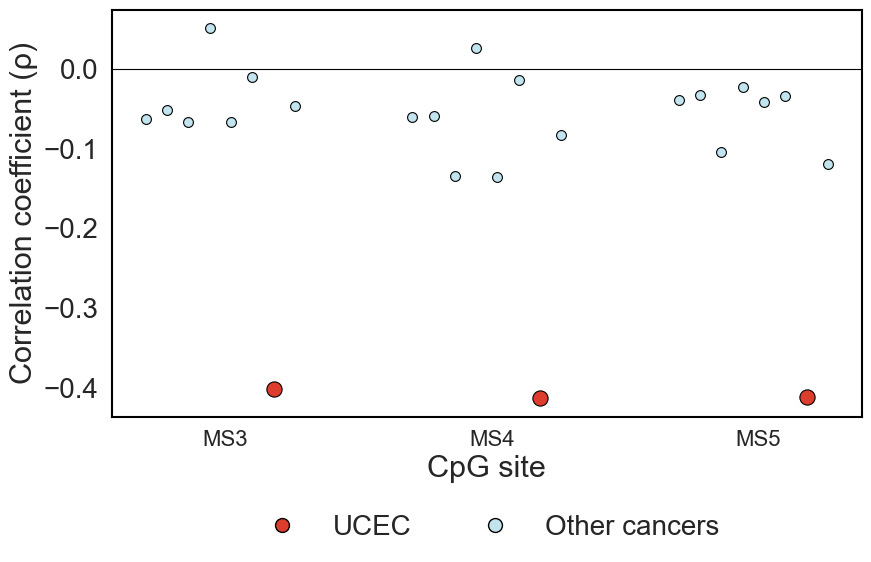

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================
# Configuration
# =============================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

cancer_types = ['BRCA', 'COAD', 'HNSC', 'LUAD', 'KIRC', 'PRAD', 'UCEC', 'ESCA']
proximal_sites = ['cg06908460', 'cg13849253', 'cg09566069']
xtick_labels = ['MS3', 'MS4', 'MS5']
base_path = r"C:\Users\jlapi\Desktop\KIRC_Gene_Methylation_Correlations2.xlsx"

# =============================
# Helper function
# =============================
def parse_correlation(value):
    if pd.isna(value) or value == '':
        return np.nan, 0
    s = str(value).strip()
    corr = float(s.split()[0])
    sig = 3 if '***' in s else 2 if '**' in s else 1 if '*' in s else 0
    return corr, sig

# =============================
# Load data
# =============================
data = {
    cancer: pd.read_excel(base_path.replace('KIRC', cancer)).pipe(
        lambda df: df.set_index(df.columns[0])
    )
    for cancer in cancer_types
}

# =============================
# Plot
# =============================
fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
ax.set_facecolor('white')

for i, cpg in enumerate(proximal_sites):
    for j, cancer in enumerate(cancer_types):
        corr, _ = parse_correlation(data[cancer].loc['MLH1', cpg])
        is_ucec = cancer == 'UCEC'
        ax.scatter(
            i + j * 0.08 - 0.3, corr,
            s=120 if is_ucec else 50,
            color='#DD3D2D' if is_ucec else '#C2E4EF',
            edgecolor='black', linewidth=0.8,
            zorder=3 if is_ucec else 2,
        )

# Axes
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(proximal_sites)))
ax.set_xticklabels(xtick_labels, rotation=0, ha='center', fontsize=25)
ax.set_ylabel('Correlation coefficient (ρ)', fontsize=22)
ax.set_xlabel('CpG site', fontsize=22)
ax.tick_params(labelsize=16, top=False, right=False)
ax.yaxis.set_tick_params(labelsize=20)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DD3D2D',
           markeredgecolor='black', markersize=10, label='UCEC'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C2E4EF',
           markeredgecolor='black', markersize=10, label='Other cancers'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=20,
          loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
# Chemotherapy resistance - gaining data

In [61]:
import pandas as pd

# Step 1: Filter chemotherapy treatments
df = pd.read_csv(r"C:\Users\jlapi\Desktop\tcga_luad_treatment_outcomes.csv")
filtered_df = df[df["treatment_type"] == "Chemotherapy"]

# Step 2: Merge with KIRC final merged Excel file
xlsx_df = pd.read_excel(r"C:\Users\jlapi\Desktop\XENA\LUAD\FINAL\LUAD_final_merged.xlsx")
merged_df = pd.merge(xlsx_df, filtered_df, on="case_id", how="inner")

# Step 3: Save result
merged_df.to_excel(r"C:\Users\jlapi\Desktop\LUAD_final_merged_chemotherapy2.xlsx", index=False)

print(f"Merged shape: {merged_df.shape}")
print(merged_df.head())

Merged shape: (408, 110)
             sample  CA9_Expression                                    id  \
0  TCGA-38-7271-01A        0.226509  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
1  TCGA-38-7271-01A        0.226509  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
2  TCGA-38-7271-01A        0.226509  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
3  TCGA-55-7914-01A        1.933233  69dba721-a168-47a4-b7ff-80a448bad654   
4  TCGA-55-7914-01A        1.933233  69dba721-a168-47a4-b7ff-80a448bad654   

                   disease_type                               case_id  \
0  Adenomas and Adenocarcinomas  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
1  Adenomas and Adenocarcinomas  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
2  Adenomas and Adenocarcinomas  8214a0d1-5e2d-4a7a-acb1-e5580755db83   
3  Adenomas and Adenocarcinomas  69dba721-a168-47a4-b7ff-80a448bad654   
4  Adenomas and Adenocarcinomas  69dba721-a168-47a4-b7ff-80a448bad654   

  submitter_id_x       primary_site  cigarettes_per_day.exposures  \
0   

In [ ]:
# Chemotherapy outcomes

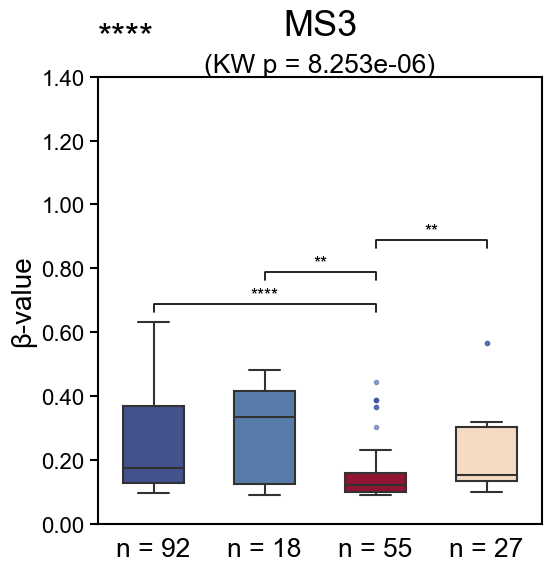

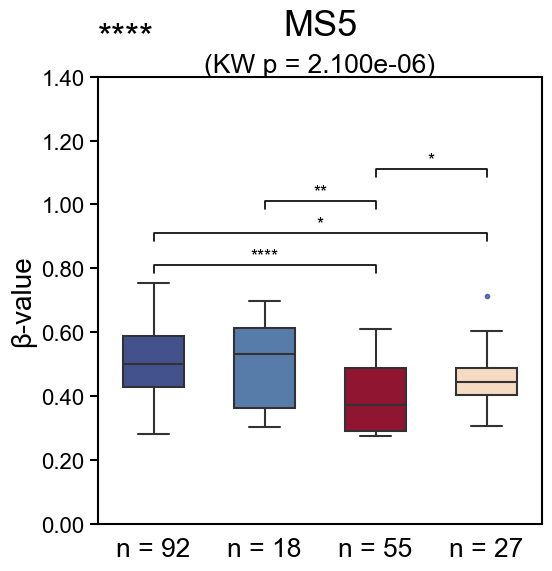

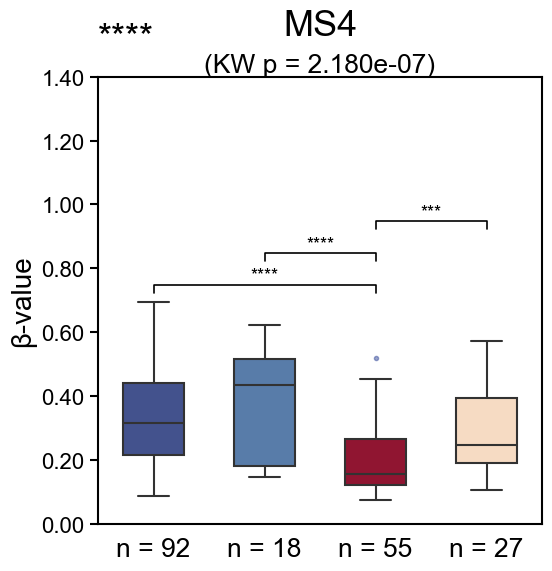

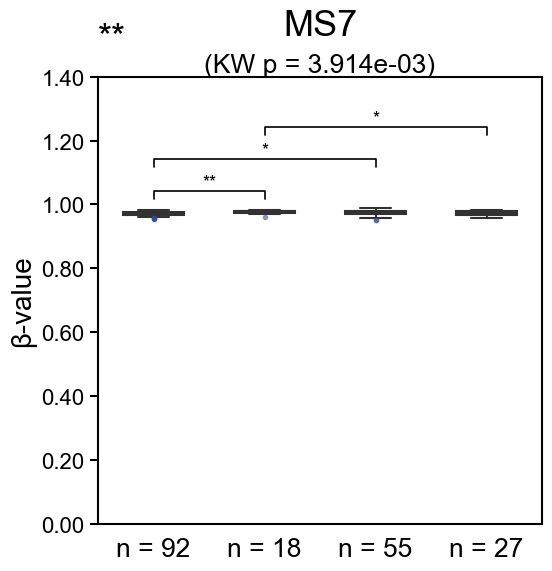

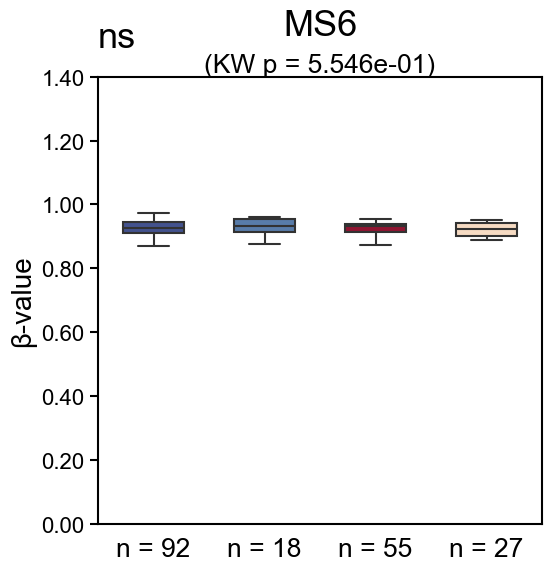

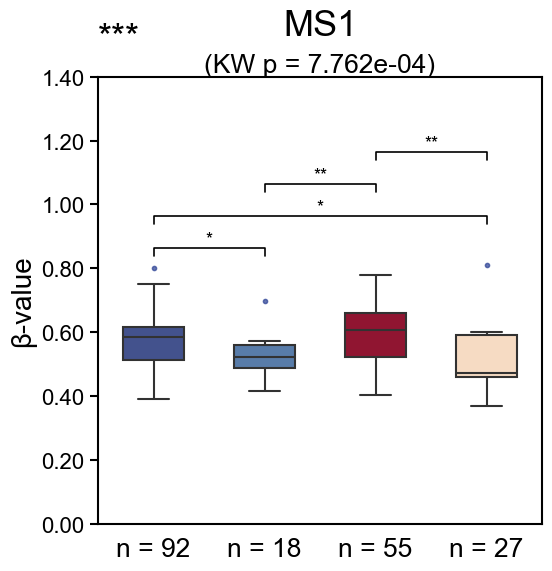

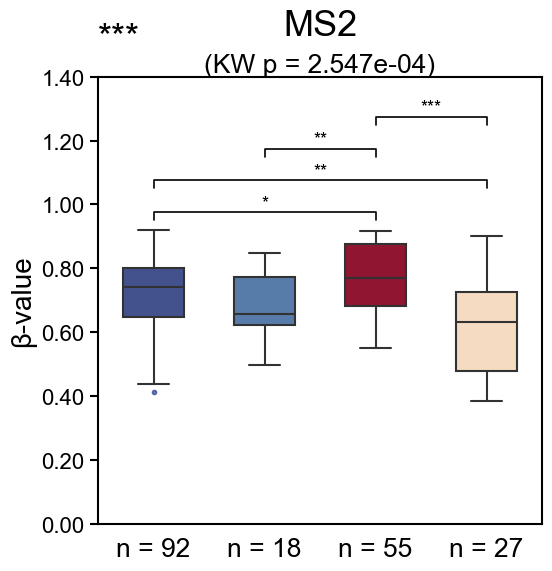

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'

# ================================================
# LOAD & CLEAN
# ================================================
df = pd.read_excel(
    r"C:\Users\jlapi\Desktop\LUAD_final_merged_chemotherapy2.xlsx"
)

df["treatment_outcome"] = df["treatment_outcome"].astype(str).str.strip()
df["therapeutic_agents"] = df["therapeutic_agents"].astype(str).str.strip()

df_filtered = df[
    ~df["therapeutic_agents"].isin(["nan", "None", "Unknown", ""])
    & ~df["treatment_outcome"].isin(
        ["nan", "None", "Unknown", "", "Treatment Ongoing"]
    )
].copy()

cpg_cols = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
]

ms_labels = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7",
}

outcome_palette = {
    "Complete Response":   "#364B9A",
    "Partial Response":    "#4A7BB7",
    "Stable Disease":      "#FEDABB",
    "Progressive Disease": "#A50026",
}

# ================================================
# REMOVE OUTLIERS (IQR)
# ================================================
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[
        (data[column] >= Q1 - 1.5 * IQR) &
        (data[column] <= Q3 + 1.5 * IQR)
    ]

for cpg in cpg_cols:
    df_filtered = remove_outliers(df_filtered, cpg)

# ================================================
# HELPER FUNCTIONS
# ================================================
def get_asterisks(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "ns"

def add_significance_bracket(ax, x1, x2, y, pval, h=0.025):
    stars = get_asterisks(pval)
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text(
        (x1 + x2) / 2, y + h, stars,
        ha="center", va="bottom", fontsize=13, color="black"
    )

# ================================================
# PLOTS
# ================================================
display_order = [
    "Complete Response", "Partial Response",
    "Progressive Disease", "Stable Disease",
]

# Keep only outcomes present in the data
display_order = [
    o for o in display_order
    if o in df_filtered["treatment_outcome"].unique()
]

for cpg in cpg_cols:
    ms_name = ms_labels[cpg]

    # Kruskal-Wallis (groups with n >= 2 only)
    group_arrays = [
        df_filtered[df_filtered["treatment_outcome"] == g][cpg].dropna().values
        for g in display_order
        if len(df_filtered[df_filtered["treatment_outcome"] == g][cpg].dropna()) >= 2
    ]
    if len(group_arrays) < 2:
        continue
    kw_stat, kw_p = kruskal(*group_arrays)

    # Pairwise Mann-Whitney U (raw p-value, no correction)
    sig_pairs = []
    for g1, g2 in [
        (display_order[i], display_order[j])
        for i in range(len(display_order))
        for j in range(i + 1, len(display_order))
    ]:
        d1 = df_filtered[df_filtered["treatment_outcome"] == g1][cpg].dropna()
        d2 = df_filtered[df_filtered["treatment_outcome"] == g2][cpg].dropna()
        if len(d1) < 2 or len(d2) < 2:
            continue
        _, p_raw = mannwhitneyu(d1, d2, alternative="two-sided")
        if p_raw < 0.05:
            sig_pairs.append((g1, g2, p_raw))

    # Figure
    n_groups = len(display_order)
    fig_width = 1.2 + 1.0 * n_groups + 0.6
    fig, ax = plt.subplots(figsize=(fig_width, 6.0))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    sns.boxplot(
        data=df_filtered,
        x="treatment_outcome",
        y=cpg,
        palette=outcome_palette,
        order=display_order,
        width=0.55,
        linewidth=1.5,
        flierprops=dict(
            marker="o", markersize=3, alpha=0.5,
            markerfacecolor="#364B9A", markeredgecolor="#364B9A",
        ),
        legend=False,
        ax=ax,
    )

    # Significance brackets
    max_y = df_filtered[cpg].max()
    bracket_y = max_y + 0.03
    for g1, g2, p_raw in sig_pairs:
        x1 = display_order.index(g1)
        x2 = display_order.index(g2)
        add_significance_bracket(ax, x1, x2, bracket_y, p_raw)
        bracket_y += 0.10

    # KW annotation
    ax.text(
        0.0, 1.05, get_asterisks(kw_p),
        fontsize=26, color="black", transform=ax.transAxes,
        va="bottom", ha="left",
    )
    ax.set_title(f"{ms_name}", fontsize=26, color="black", pad=30)
    ax.text(
        0.5, 1.0, f"(KW p = {kw_p:.3e})",
        fontsize=19, color="black", transform=ax.transAxes,
        va="bottom", ha="center",
    )

    # Axes formatting
    ax.set_xlabel("", fontsize=20, color="black")
    ax.set_ylabel("β-value", fontsize=20, color="black")
    ax.set_ylim(0, max(bracket_y + 0.05, 1.40))
    ax.set_xlim(-0.5, n_groups - 0.5)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))
    ax.tick_params(
        colors="black", labelsize=16,
        top=False, right=False, left=True, bottom=False,
    )

    n_labels = [
        f"n = {len(df_filtered[df_filtered['treatment_outcome'] == o][cpg].dropna())}"
        for o in display_order
    ]
    ax.set_xticks(range(n_groups))
    ax.set_xticklabels(n_labels, fontsize=19, color="black")

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)

    ax.grid(False)
    plt.tight_layout()
    plt.show()

In [ ]:
# KM curves

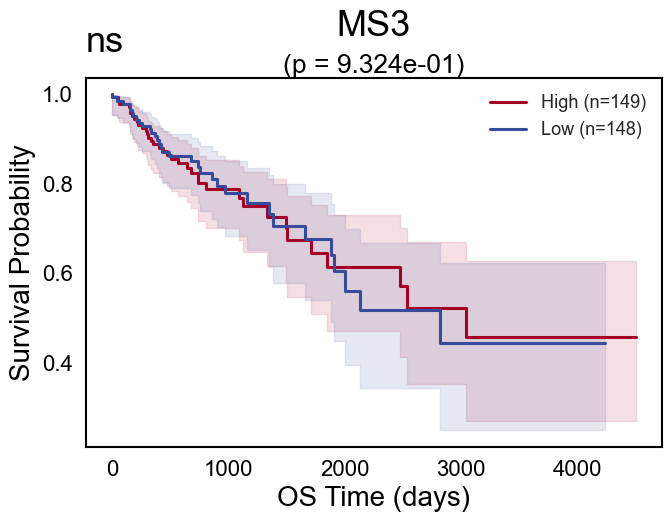

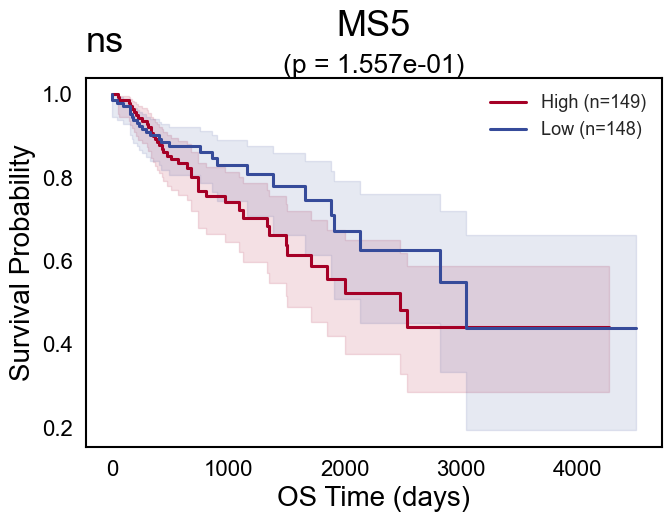

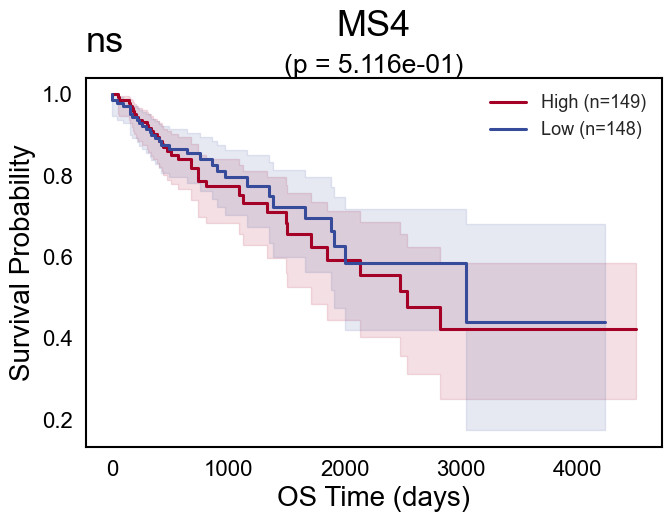

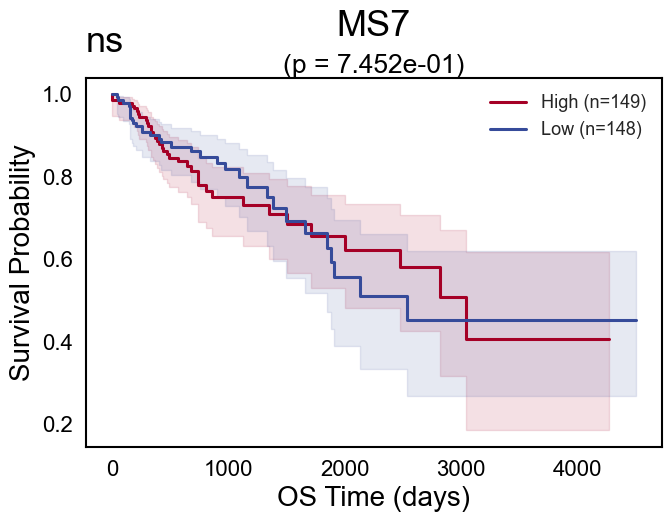

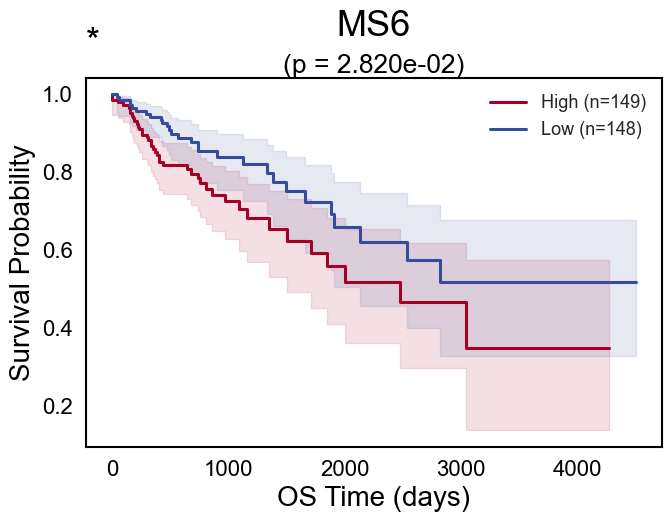

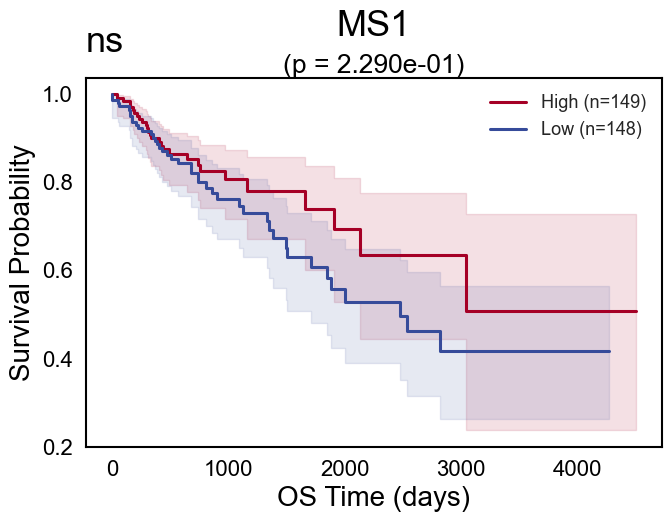

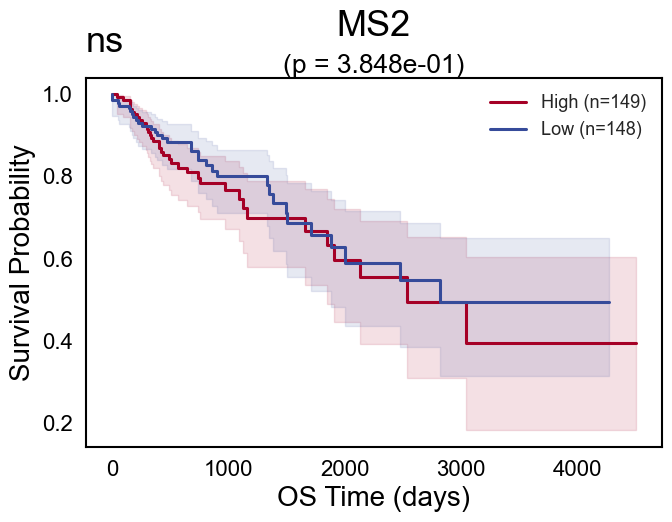

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'

# ================================================
# 1️⃣ LOAD DATA
# ================================================
file_path = r"C:\Users\jlapi\Desktop\XENA\COAD\FINAL\COAD_final_merged.xlsx"
df = pd.read_excel(file_path)

df_filtered = df[df["sample_type.samples"] == "Primary Tumor"].copy()

methylation_probes = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181"
]

ms_labels = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7"
}

COLOR_HIGH = "#A50026"
COLOR_LOW  = "#364B9A"

# ================================================
# 2️⃣ PREPARE SURVIVAL COLUMNS
# ================================================
df_filtered["OS_event"] = (
    df_filtered["vital_status.demographic"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"dead": 1, "alive": 0})
)

# ================================================
# 3️⃣ HELPER — asterisks
# ================================================
def get_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ================================================
# 4️⃣ KAPLAN-MEIER PLOTS
# ================================================
for probe in methylation_probes:
    ms_name = ms_labels[probe]

    df_km = df_filtered[[probe, "OS.time", "OS_event"]].dropna().copy()

    median_val = df_km[probe].median()
    df_km["group"] = np.where(df_km[probe] >= median_val, "High", "Low")

    high = df_km[df_km["group"] == "High"]
    low  = df_km[df_km["group"] == "Low"]

    n_high = len(high)
    n_low  = len(low)

    results = logrank_test(
        high["OS.time"], low["OS.time"],
        event_observed_A=high["OS_event"],
        event_observed_B=low["OS_event"]
    )

    p_val = results.p_value
    stars = get_asterisks(p_val)

    kmf_high = KaplanMeierFitter()
    kmf_low  = KaplanMeierFitter()

    kmf_high.fit(
        high["OS.time"],
        event_observed=high["OS_event"],
        label=f"High (n={n_high})"
    )
    kmf_low.fit(
        low["OS.time"],
        event_observed=low["OS_event"],
        label=f"Low (n={n_low})"
    )

    # ── PLOT ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5.5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    kmf_high.plot_survival_function(
        ax=ax, ci_show=True,
        color=COLOR_HIGH, linewidth=2.2, ci_alpha=0.12
    )
    kmf_low.plot_survival_function(
        ax=ax, ci_show=True,
        color=COLOR_LOW, linewidth=2.2, ci_alpha=0.12
    )

    ax.text(
        0.0, 1.05, stars,
        fontsize=26, color="black",
        transform=ax.transAxes,
        va="bottom", ha="left"
    )

    ax.set_title(f"{ms_name}", fontsize=26, color="black", pad=30)

    ax.text(
        0.5, 1.0,
        f"(p = {p_val:.3e})",
        fontsize=19, color="black",
        transform=ax.transAxes,
        va="bottom", ha="center"
    )

    ax.set_xlabel("OS Time (days)", fontsize=20, color="black")
    ax.set_ylabel("Survival Probability", fontsize=20, color="black")

    ax.tick_params(colors="black", labelsize=16, top=False, right=False)

    ax.legend(fontsize=13, frameon=False, loc="upper right")

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)
        spine.set_visible(True)

    ax.grid(False)
    plt.tight_layout()

    plt.show()

In [ ]:
# Univariate Cox analysis

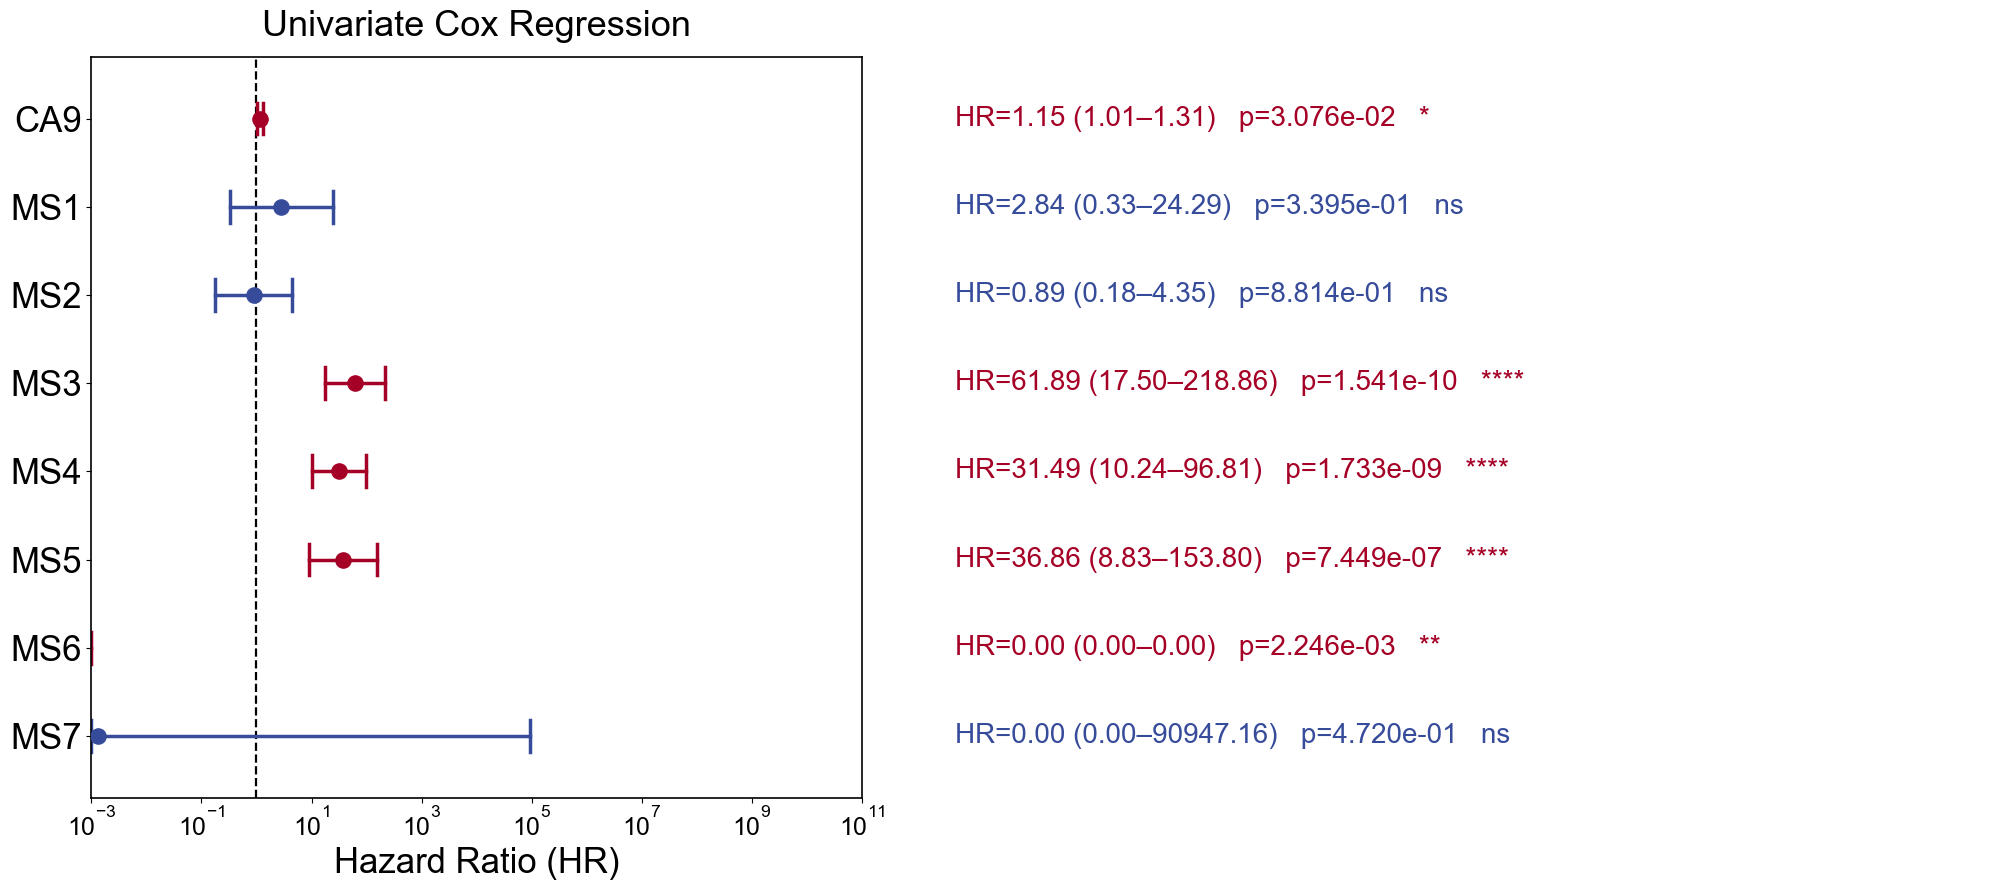

In [3]:
# KIRP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from lifelines import CoxPHFitter

matplotlib.rcParams['font.family'] = 'Arial'

# ================================================
# 1️⃣ LOAD DATA
# ================================================
file_path = r"C:\Users\jlapi\Desktop\XENA2\KIRP\KIRP_final_merged.xlsx"
df = pd.read_excel(file_path)

df_filtered = df[df["sample_type.samples"] == "Primary Tumor"].copy()

# ================================================
# 2️⃣ PREPARE VARIABLES
# ================================================
variables = [
    "cg06908460", "cg09566069", "cg13849253",
    "cg13938361", "cg14563831", "cg19257550", "cg20610181",
    "CA9_Expression"
]

ms_labels = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7", "CA9_Expression": "CA9"
}

df_filtered["OS_event"] = (
    df_filtered["vital_status.demographic"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"dead": 1, "alive": 0})
)

# ================================================
# 3️⃣ RUN UNIVARIATE COX FOR EACH VARIABLE
# ================================================
results = []

for var in variables:
    cols = [var, "OS.time", "OS_event"]
    df_cox = df_filtered[cols].dropna().copy()

    if df_cox["OS_event"].sum() == 0:
        continue

    cph = CoxPHFitter()
    cph.fit(df_cox, duration_col="OS.time", event_col="OS_event")

    summary = cph.summary.loc[var]

    results.append({
        "variable":  ms_labels[var],
        "HR":        np.exp(summary["coef"]),
        "CI_lower":  np.exp(summary["coef lower 95%"]),
        "CI_upper":  np.exp(summary["coef upper 95%"]),
        "p_value":   summary["p"],
    })

results_df = pd.DataFrame(results)

# ================================================
# 4️⃣ SIGNIFICANCE STARS
# ================================================
def get_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

results_df["stars"] = results_df["p_value"].apply(get_asterisks)

# ================================================
# 5️⃣ ORDER ROWS
# ================================================
display_order = ["CA9", "MS1", "MS2", "MS3", "MS4", "MS5", "MS6", "MS7"]

results_df["variable"] = pd.Categorical(
    results_df["variable"],
    categories=display_order,
    ordered=True
)
results_df = results_df.sort_values("variable", ascending=False).reset_index(drop=True)

# ================================================
# 6️⃣ FOREST PLOT
# ================================================
COLOR_SIG   = "#A50026"
COLOR_NOSIG = "#364B9A"

X_MIN = 1e-3
X_MAX = 1e11

fig, (ax, ax_text) = plt.subplots(
    1, 2,
    figsize=(20, 9),
    gridspec_kw={"width_ratios": [1, 1.4]}
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax_text.set_facecolor("white")

y_pos = np.arange(len(results_df))
tick_height = 0.18

for i, row in results_df.iterrows():
    color = COLOR_SIG if row["p_value"] < 0.05 else COLOR_NOSIG

    ci_lower_plot = max(row["CI_lower"], X_MIN * 1.01)
    ci_upper_plot = min(row["CI_upper"], X_MAX * 0.99)

    # Horizontal CI line
    ax.plot(
        [ci_lower_plot, ci_upper_plot],
        [i, i],
        color=color, linewidth=2.5, zorder=2
    )

    # End ticks
    ax.plot(
        [ci_lower_plot, ci_lower_plot],
        [i - tick_height, i + tick_height],
        color=color, linewidth=2.5, zorder=2
    )
    ax.plot(
        [ci_upper_plot, ci_upper_plot],
        [i - tick_height, i + tick_height],
        color=color, linewidth=2.5, zorder=2
    )

    # HR point
    ax.scatter(
        row["HR"], i,
        color=color, s=120, zorder=3
    )

    # Annotation text in right panel
    label = (
        f"HR={row['HR']:.2f} ({row['CI_lower']:.2f}–{row['CI_upper']:.2f})"
        f"   p={row['p_value']:.3e}   {row['stars']}"
    )
    ax_text.text(
        0.05, i,
        label,
        va="center", ha="left",
        fontsize=20, color=color,
        fontfamily="Arial"
    )

# Reference line HR=1
ax.axvline(x=1, color="black", linestyle="--", linewidth=1.6, zorder=1)

# Axis formatting
ax.set_xscale("log")
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(-0.7, len(results_df) - 0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(results_df["variable"], fontsize=20)
ax.set_xlabel("Hazard Ratio (HR)", fontsize=25, color="black")
ax.set_title("Univariate Cox Regression", fontsize=26, color="black", pad=15)

# X tick label size
ax.tick_params(axis='x', labelsize=18, top=False, right=False)
ax.tick_params(axis='y', labelsize=25, top=False, right=False)

# Top and right spines visible but NO ticks
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["top"].set_edgecolor("black")
ax.spines["right"].set_edgecolor("black")
ax.spines["top"].set_linewidth(1.2)
ax.spines["right"].set_linewidth(1.2)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_edgecolor("black")
    ax.spines[spine].set_linewidth(1.2)

ax.grid(False)

# Right text panel — hide axes
ax_text.set_xlim(0, 1)
ax_text.set_ylim(-0.7, len(results_df) - 0.3)
ax_text.axis("off")

plt.tight_layout()
plt.savefig(
    r"C:\Users\jlapi\Desktop\Figure12_UnivariateCox.tiff",
    dpi=1000,
    format="tiff",
    bbox_inches="tight"
)
plt.show()

In [5]:
# Multivariate Cox Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from lifelines import CoxPHFitter

matplotlib.rcParams['font.family'] = 'Arial'

# ================================================
# 1️⃣ LOAD DATA
# ================================================
file_path = r"C:\Users\jlapi\Desktop\XENA2\KIRP\KIRP_final_merged.xlsx"
df = pd.read_excel(file_path)

df_filtered = df[df["sample_type.samples"] == "Primary Tumor"].copy()

# ================================================
# 2️⃣ PREPARE VARIABLES
# ================================================

# Map CpG probe IDs → display labels
ms_labels = {
    "cg19257550": "MS1", "cg20610181": "MS2", "cg06908460": "MS3",
    "cg13849253": "MS4", "cg09566069": "MS5", "cg14563831": "MS6",
    "cg13938361": "MS7", "CA9_Expression": "CA9"
}

# Rename columns so we can reference them by display name
df_filtered = df_filtered.rename(columns=ms_labels)

df_filtered["OS_event"] = (
    df_filtered["vital_status.demographic"]
    .astype(str).str.strip().str.lower()
    .map({"dead": 1, "alive": 0})
)

# Bin age into quintiles (Q1–Q5)
df_filtered["age_cat"] = pd.qcut(
    df_filtered["age_at_index.demographic"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
)

# Clean up stage column
df_filtered["Stage"] = (
    df_filtered["ajcc_pathologic_stage.diagnoses"]
    .astype(str).str.strip()
    .str.replace("Stage ", "", regex=False)
    .str.replace("A", "", regex=False)
    .str.replace("B", "", regex=False)
    .str.replace("C", "", regex=False)
    .str.strip()
)
df_filtered = df_filtered[df_filtered["Stage"].isin(["I", "II", "III", "IV"])]
df_filtered["Stage"] = pd.Categorical(
    df_filtered["Stage"],
    categories=["I", "II", "III", "IV"],
    ordered=True
)

# ================================================
# 3️⃣ PREPARE MULTIVARIATE DATAFRAME
# ================================================

# Only include MS/CA9 variables that actually exist in this dataset
ms_vars = [v for v in ["MS2", "MS5", "MS6", "MS7"] if v in df_filtered.columns]
ca9_vars = ["CA9"] if "CA9" in df_filtered.columns else []

data_cox = df_filtered[[
    "OS.time", "OS_event",
    "age_cat",
    "Stage",
    *ca9_vars,
    *ms_vars
]].dropna().copy()

data_cox = pd.get_dummies(data_cox, columns=["age_cat", "Stage"], drop_first=True)

# Ensure boolean dummies are int (lifelines compatibility)
bool_cols = data_cox.select_dtypes(include="bool").columns
data_cox[bool_cols] = data_cox[bool_cols].astype(int)

print("Columns after get_dummies:", data_cox.columns.tolist())

# ================================================
# 4️⃣ FIT MULTIVARIATE COX MODEL
# ================================================
cph = CoxPHFitter(penalizer=0.1)
cph.fit(data_cox, duration_col="OS.time", event_col="OS_event")

summary = cph.summary.copy()
summary["HR"]       = np.exp(summary["coef"])
summary["CI_lower"] = np.exp(summary["coef lower 95%"])
summary["CI_upper"] = np.exp(summary["coef upper 95%"])
summary["p_value"]  = summary["p"]

# ================================================
# 5️⃣ ORDER ROWS & CLEAN LABELS
# ================================================
desired_order = [
    "Stage_II", "Stage_III", "Stage_IV",
    "age_cat_Q2", "age_cat_Q3", "age_cat_Q4", "age_cat_Q5",
    *ca9_vars,
    *ms_vars
]

# Only keep rows that actually exist in the summary
desired_order = [r for r in desired_order if r in summary.index]
summary = summary.reindex(desired_order).dropna(subset=["HR"])

label_map = {
    "Stage_II":   "Stage II",
    "Stage_III":  "Stage III",
    "Stage_IV":   "Stage IV",
    "age_cat_Q2": "Age Q2",
    "age_cat_Q3": "Age Q3",
    "age_cat_Q4": "Age Q4",
    "age_cat_Q5": "Age Q5",
    "CA9":        "CA9",
    "MS2":        "MS2",
    "MS5":        "MS5",
    "MS6":        "MS6",
    "MS7":        "MS7",
}

idx_series = pd.Series(summary.index, index=summary.index)
summary["display_label"] = idx_series.map(label_map).fillna(idx_series)

# Reverse for bottom-to-top orientation
summary = summary.iloc[::-1].reset_index(drop=True)

# ================================================
# 6️⃣ SIGNIFICANCE STARS
# ================================================
def get_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

summary["stars"] = summary["p_value"].apply(get_asterisks)

# ================================================
# 7️⃣ FOREST PLOT
# ================================================
COLOR_SIG   = "#A50026"
COLOR_NOSIG = "#364B9A"

X_MIN = 1e-3
X_MAX = 1e11

fig, (ax, ax_text) = plt.subplots(
    1, 2,
    figsize=(20, 9),
    gridspec_kw={"width_ratios": [1, 1.4]}
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax_text.set_facecolor("white")

y_pos       = np.arange(len(summary))
tick_height = 0.18

for i, row in summary.iterrows():
    color = COLOR_SIG if row["p_value"] < 0.05 else COLOR_NOSIG

    ci_lower_plot = max(row["CI_lower"], X_MIN * 1.01)
    ci_upper_plot = min(row["CI_upper"], X_MAX * 0.99)

    ax.plot(
        [ci_lower_plot, ci_upper_plot], [i, i],
        color=color, linewidth=2.5, zorder=2
    )
    ax.plot(
        [ci_lower_plot, ci_lower_plot],
        [i - tick_height, i + tick_height],
        color=color, linewidth=2.5, zorder=2
    )
    ax.plot(
        [ci_upper_plot, ci_upper_plot],
        [i - tick_height, i + tick_height],
        color=color, linewidth=2.5, zorder=2
    )
    ax.scatter(row["HR"], i, color=color, s=120, zorder=3)

    label = (
        f"HR={row['HR']:.2f} ({row['CI_lower']:.2f}–{row['CI_upper']:.2f})"
        f"   p={row['p_value']:.3e}   {row['stars']}"
    )
    ax_text.text(
        0.05, i, label,
        va="center", ha="left",
        fontsize=20, color=color,
        fontfamily="Arial"
    )

ax.axvline(x=1, color="black", linestyle="--", linewidth=1.6, zorder=1)

ax.set_xscale("log")
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(-0.7, len(summary) - 0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(summary["display_label"], fontsize=20)
ax.set_xlabel("Hazard Ratio (HR)", fontsize=25, color="black")
ax.set_title("Multivariate Cox Regression", fontsize=26, color="black", pad=15)

ax.tick_params(axis='x', labelsize=18, top=False, right=False)
ax.tick_params(axis='y', labelsize=25, top=False, right=False)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["top"].set_edgecolor("black")
ax.spines["right"].set_edgecolor("black")
ax.spines["top"].set_linewidth(1.2)
ax.spines["right"].set_linewidth(1.2)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_edgecolor("black")
    ax.spines[spine].set_linewidth(1.2)

ax.grid(False)

ax_text.set_xlim(0, 1)
ax_text.set_ylim(-0.7, len(summary) - 0.3)
ax_text.axis("off")

plt.tight_layout()
plt.savefig(
    r"C:\Users\jlapi\Desktop\Figure13_MultivariateCox.tiff",
    dpi=1000,
    format="tiff",
    bbox_inches="tight"
)
plt.show()